In [199]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)


setup_styles()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [200]:
def get_canonical_and_perturbed_df(
    samples,
    only_keep_canonical_true: bool = False,
    keep_remains_or_becomes_correct: bool = False,
    only_keep_perturbed_true: bool = False,
):
    """returns filtered out samples too"""
    if (
        (only_keep_canonical_true and keep_remains_or_becomes_correct)
        or (only_keep_canonical_true and only_keep_perturbed_true)
        or (keep_remains_or_becomes_correct and only_keep_perturbed_true)
    ):
        raise ValueError(
            f"Please pass these exclusively, only_keep_canonical_true: true for canonical, model_name true, keep_remains_or_becomes_correct: True to include the ones where the perturbed version becomes correct"
        )
    print(f"Processing {len(samples)} examples")
    canonical_samples = samples[samples["is_canonical"]]
    perturbed_samples = samples[~samples["is_canonical"]]
    canonical_values = canonical_samples[["set_id", "model_name", METRIC]].rename(
        columns={METRIC: f"canonical_{METRIC}"}
    )

    perturbed_samples = perturbed_samples.merge(
        canonical_values, on=["set_id", "model_name"], how="left"
    )
    perturbed_samples[f"canonical-perturbed_{METRIC}"] = (
        perturbed_samples[f"canonical_{METRIC}"] - perturbed_samples[METRIC]
    )

    if only_keep_canonical_true:
        print(
            f"Cleaning samples, will be dropping entries (set_id-model pairs) where the canonical is predicted wrong."
        )
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]
        print(
            f"Keeping {len(correct_canonical_pairs)} correct pairs, dropping {len(canonical_samples) - len(correct_canonical_pairs)} entries."
        )

        canonical_samples = canonical_samples[canonical_samples[METRIC] == 1]

        # Step 3: Filter perturbed_samples to keep only rows with correct canonical pairs
        # Method 1: Using merge (RECOMMENDED)
        perturbed_samples = perturbed_samples.merge(
            correct_canonical_pairs,
            on=["set_id", "model_name"],
            how="inner",  # Only keep rows that exist in both
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)

    if keep_remains_or_becomes_correct:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]

        # Combine: pairs that either remain correct OR become correct
        remains_or_becomes_correct = pd.concat(
            [correct_canonical_pairs, correct_perturbed_pairs]
        ).drop_duplicates()

        # Filter both datasets to only include these pairs
        canonical_samples = canonical_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        perturbed_samples = perturbed_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)
        print(f"After filtering:{len(samples)}")
    if only_keep_perturbed_true:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        wrong_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 0][
            ["set_id", "model_name"]
        ]
        # Find cases where canonical wrong AND perturbed correct (recovery cases)
        becomes_correct = pd.merge(
            wrong_canonical_pairs,
            correct_perturbed_pairs,
            how="inner",
            on=["set_id", "model_name"], 
        )
        print(becomes_correct)

        # Filter both datasets to only include recovery cases
        canonical_samples = canonical_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        print(canonical_samples[METRIC].sum())

        perturbed_samples = perturbed_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        samples = pd.concat([canonical_samples, perturbed_samples], ignore_index=True)
        print(f"After filtering: {len(samples)}")

    return samples, canonical_samples, perturbed_samples

## Benchmark Subset

In [201]:
METRIC = "acc_norm"
OUTPUT_DIR_ = Path("./output/prelim-results-v5")
OUTPUT_DIR_ = Path("./output/paper-results-v5")

# keeps set_id, model pairs that are correct for canonical
suffix = "(Still correct)"
only_keep_canonical_true = True
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

# suffix = "(Remains or Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = True
# only_keep_perturbed_true = False

# suffix = "(Flipped to correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True

# keep all the samples
# suffix = "(All)" 
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = False


# code_pattern = "*tokenizer_robustness_completion_farsi*"
# title_pattern = "Farsi - "
# OUTPUT_DIR = OUTPUT_DIR_/"farsi"

# code_pattern = "*tokenizer_robustness_completion_turkish*"
# title_pattern = "Turkish - "
# OUTPUT_DIR = OUTPUT_DIR_/"turkish"

# code_pattern = "*tokenizer_robustness_completion_stem*"
# title_pattern = "STEM - "
# OUTPUT_DIR = OUTPUT_DIR_/"stem"

# code_pattern = "*tokenizer_robustness_completion_math*"
# title_pattern = "MATH - "
# OUTPUT_DIR = OUTPUT_DIR_/"math"

code_pattern = "*tokenizer_robustness_completion_english*"
title_pattern = "English - "
OUTPUT_DIR = OUTPUT_DIR_/"english"

# code_pattern = "*tokenizer_robustness_completion_chinese*"
# title_pattern = "Chinese - "
# OUTPUT_DIR = OUTPUT_DIR_/"chinese"

# code_pattern = "*tokenizer_robustness_completion_italian*"
# title_pattern = "Italian - "

# # OUTPUT_DIR = OUTPUT_DIR_/"italian"
# code_pattern = "*"
# title_pattern = "All Datasets"
# OUTPUT_DIR = OUTPUT_DIR_/"all"

SUFFIX = suffix.lower().replace("(","").replace(")","")
OUTPUT_DIR = OUTPUT_DIR/SUFFIX
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
base_dir = Path("../results/paper-v5").resolve().absolute()
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(406,
 [PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_contractions_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_emoji_substitution_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_spaced_styling_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_homoglyphs_2025-09-20T00-37-11.241572.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama

In [202]:
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)

task_counts = all_samples.groupby("task")["model_name"].value_counts().groupby(level=0).mean()
valid_tasks = task_counts[task_counts>=5].index
all_samples = all_samples[all_samples["task"].isin(valid_tasks)]
all_samples["is_canonical"] = (
    all_samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
)
## exclude anything that is mistaken
all_samples = all_samples[all_samples["subcategories"] != "Turkish, Numerical formats"]
all_samples = all_samples[all_samples["task"] != "tokenizer_robustness_completion_english_space_additions"]
valid_tasks = all_samples.pivot_table(index=["model_name", "task"], values=METRIC, aggfunc="count")
all_samples = all_samples
## filter based on settings specified above
samples, canonical_df, perturbed_df = get_canonical_and_perturbed_df(
    all_samples,
    only_keep_canonical_true=only_keep_canonical_true,
    keep_remains_or_becomes_correct=keep_remains_or_becomes_correct,
    only_keep_perturbed_true=only_keep_perturbed_true,
)

samples.head()
samples["subcategories"].value_counts()
all_samples["set_id"].value_counts()

406 [PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_contractions_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_emoji_substitution_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_spaced_styling_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_english_homoglyphs_2025-09-20T00-37-11.241572.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-x

set_id
303.0    644
300.0    462
301.0    462
308.0    434
312.0    420
304.0    420
327.0    420
333.0    406
315.0    406
313.0    406
344.0    406
302.0    406
305.0    406
306.0    392
329.0    392
309.0    392
307.0    392
316.0    392
337.0    392
323.0    392
335.0    392
310.0    392
328.0    392
338.0    378
311.0    378
339.0    378
340.0    378
341.0    378
342.0    378
336.0    378
330.0    378
331.0    378
326.0    378
322.0    378
314.0    378
332.0    364
317.0    364
343.0    364
324.0    364
334.0    350
Name: count, dtype: int64

In [203]:
pv = all_samples.pivot_table(index=["model_name", "is_canonical"], values=METRIC)
pv.to_csv(OUTPUT_DIR/f"model_canonical_{METRIC}.csv")
pv

acc_norm
model_name   is_canonical          
Aya          False         0.709091
             True          0.975000
BLOOM        False         0.731818
             True          1.000000
ByT5         False         0.686364
             True          0.900000
Comma        False         0.737273
             True          0.950000
GPT-2        False         0.718182
             True          0.950000
GPT-4o       False         0.714545
             True          0.925000
Gemma-2      False         0.714545
             True          0.975000
Llama-3.2    False         0.731818
             True          1.000000
Phi-3        False         0.682727
             True          0.950000
Qwen-3       False         0.702727
             True          0.950000
Tekken       False         0.703636
             True          0.950000
TokenMonster False         0.677273
             True          0.875000
XGLM         False         0.761818
             True          0.950000
mBERT        False         0.699091
             True          0.925000

              acc_norm
model_name            
Aya           0.718421
BLOOM         0.741228
ByT5          0.693860
Comma         0.744737
GPT-2         0.726316
GPT-4o        0.721930
Gemma-2       0.723684
Llama-3.2     0.741228
Phi-3         0.692105
Qwen-3        0.711404
Tekken        0.712281
TokenMonster  0.684211
XGLM          0.768421
mBERT         0.707018


/var/folders/d7/6swf_cn561v8n6hw_bgg04lh0000gn/T/ipykernel_30275/3651672698.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=palette)


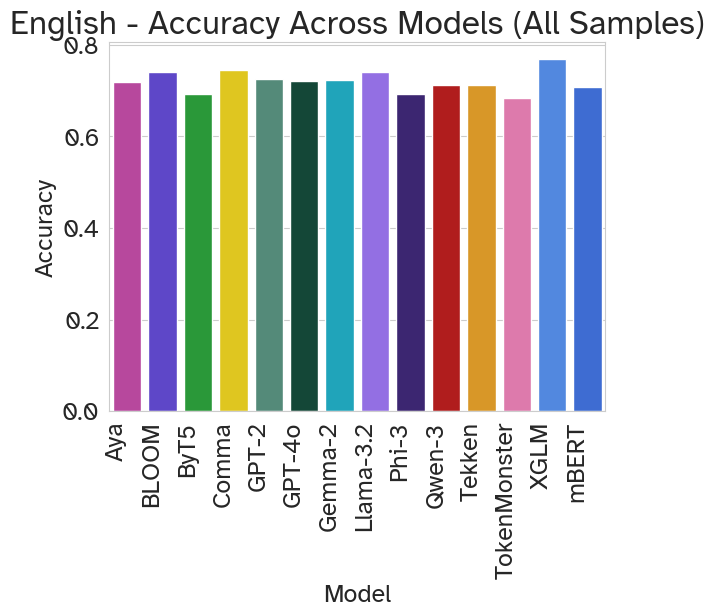

In [204]:
### Here using ALL SAMPLES

XAXIS = "model_name"
palette=MODEL_TO_COLOR
# XAXIS = "vocab_bucket"
# palette=None
accuracies_by_model = all_samples.pivot_table(
    index=XAXIS, values=METRIC, aggfunc="mean"
)
sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=palette)
# sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy")
plt.title(f"{title_pattern}Accuracy Across Models (All Samples)")
plt.savefig(OUTPUT_DIR/f"all_samples_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [205]:
samples["vocab_bucket"]

0         Large
1         Large
2         Large
3         Large
4         Large
          ...  
15139    Medium
15140    Medium
15141    Medium
15142    Medium
15143    Medium
Name: vocab_bucket, Length: 15144, dtype: object

### Canonical vs. Pertuerbed

                           acc_norm
model_name   is_canonical          
Aya          False         0.709091
             True          0.975000
BLOOM        False         0.731818
             True          1.000000
ByT5         False         0.686364
             True          0.900000
Comma        False         0.737273
             True          0.950000
GPT-2        False         0.718182
             True          0.950000
GPT-4o       False         0.714545
             True          0.925000
Gemma-2      False         0.714545
             True          0.975000
Llama-3.2    False         0.731818
             True          1.000000
Phi-3        False         0.682727
             True          0.950000
Qwen-3       False         0.702727
             True          0.950000
Tekken       False         0.703636
             True          0.950000
TokenMonster False         0.677273
             True          0.875000
XGLM         False         0.761818
             True          0

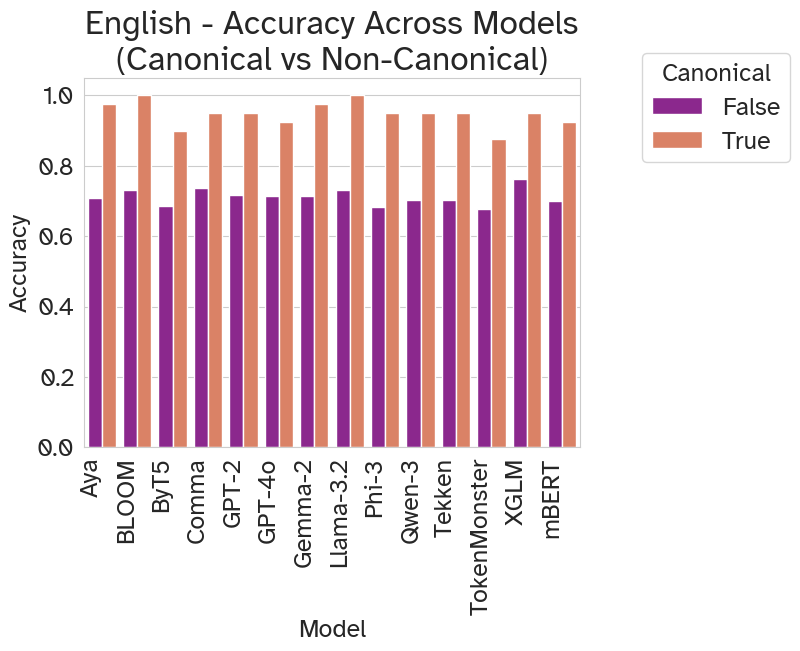

In [206]:
accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "is_canonical"], values=METRIC, aggfunc="mean"
)
# sns.barplot(accuracies_by_model, x="is_canonical", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
# xlabel = "Canonical"
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, hue="is_canonical", palette="plasma")
xlabel = "Model"
plt.xticks(rotation=90, ha="right")
plt.xlabel(xlabel)
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy Across Models\n(Canonical vs Non-Canonical)")
plt.legend(bbox_to_anchor=(1.1, 1.1), title="Canonical")
plt.savefig(OUTPUT_DIR/f"canonical_vs_perturbed_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

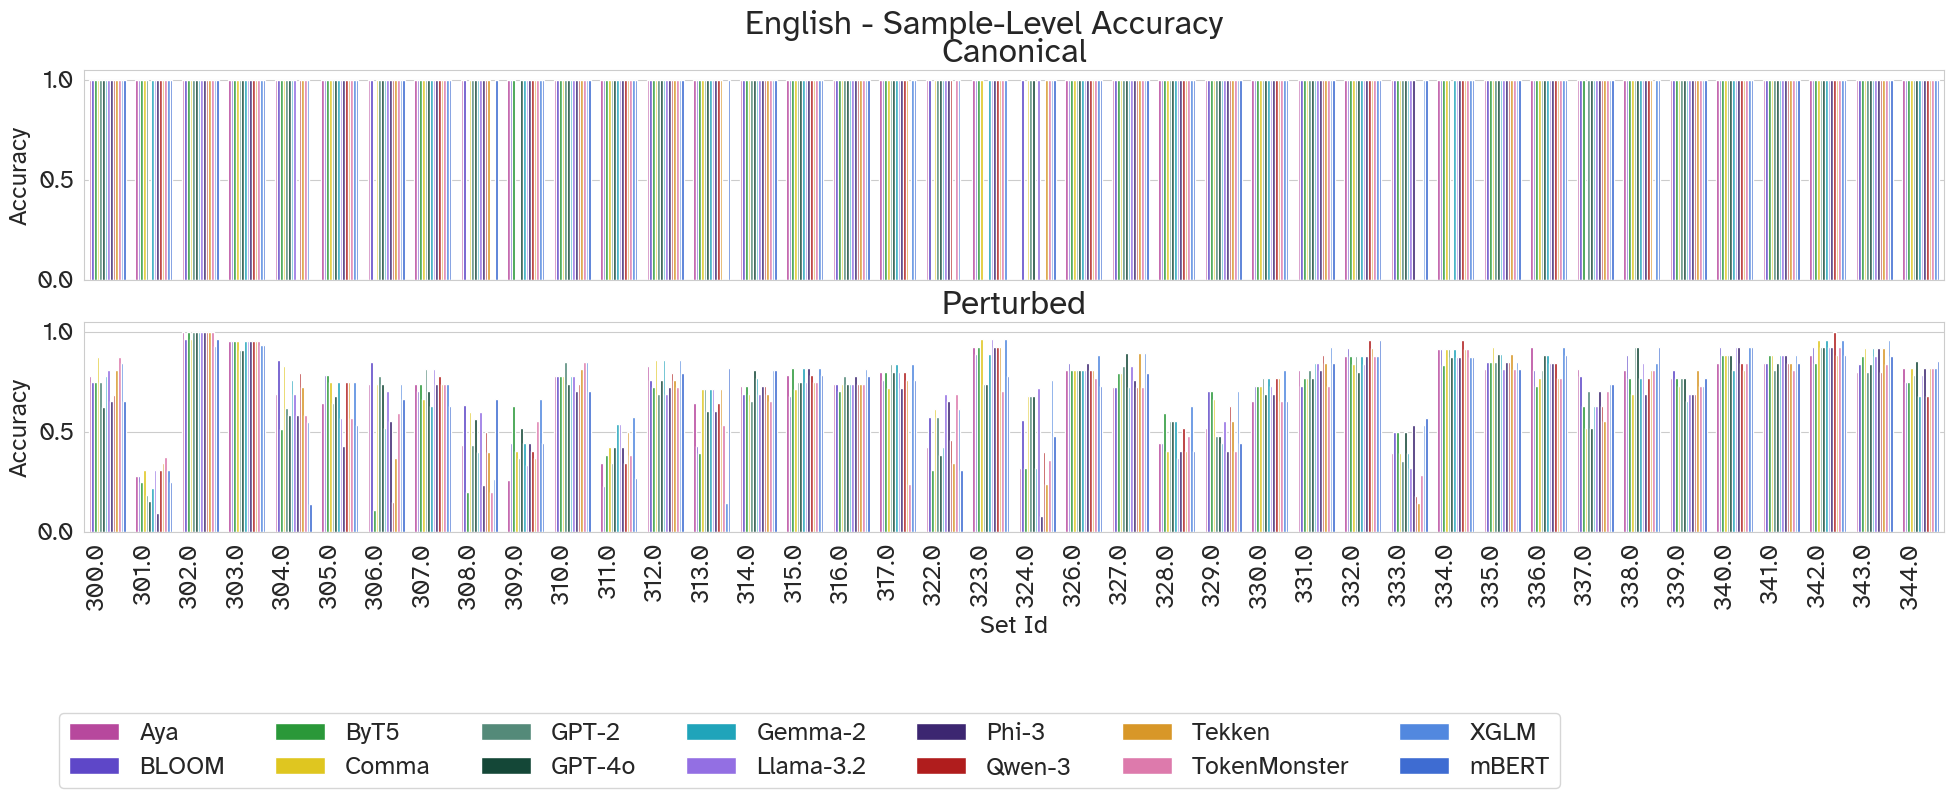

In [207]:
accuracies_by_model = all_samples.copy()
accuracies_by_model = all_samples.pivot_table(
    index=["set_id", "model_name", "is_canonical"], values=METRIC, aggfunc="mean"
).reset_index()
fig, axs = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
axs = axs.flat
sns.barplot(
    accuracies_by_model[accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[0],
    legend=False,
)
axs[0].set_title("Canonical")
axs[1].set_title("Perturbed")

sns.barplot(
    accuracies_by_model[~accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[1],
    legend=True,
)
axs[1].legend(bbox_to_anchor=(0.8, -0.8, 0, 0), ncol=7)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Set Id")
axs[0].set_ylabel(f"Accuracy")
axs[1].set_ylabel(f"Accuracy")
# Specify the questions
fig.suptitle(f"{title_pattern}Sample-Level Accuracy")
plt.savefig(OUTPUT_DIR/f"by_samples_canonical_vs_perturbed.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

In [208]:
samples

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id,canonical_acc_norm,canonical-perturbed_acc_norm
0,0,3,"[[[-5.6875, False]], [[-10.5, False]], [[-7.68...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,Dr Smith is a doctor. Occupation of Dr Smith is,...,13,11,12,11,Canonical,Large,True,0.0,NaN,NaN
1,1,1,"[[[-4.4375, False]], [[-2.0625, True]], [[-4.6...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,The color of the sky is,...,6,6,6,5,Canonical,Large,True,0.0,NaN,NaN
2,2,0,"[[[-3.84375, True]], [[-10.1875, False]], [[-1...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,"The price of this house is 1,028,415 dollars. ...",...,24,24,20,16,Canonical,Large,True,0.0,NaN,NaN
3,3,1,"[[[-9.375, False]], [[-6.0, False]], [[-9.6875...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,Today's date is 29/08/2025. Today is,...,19,18,13,14,Canonical,Large,True,0.0,NaN,NaN
4,4,2,"[[[-4.46875, False]], [[-5.84375, False]], [[-...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,The number of continents on Earth is,...,8,7,7,6,Canonical,Large,True,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15139,39,2,"[[[-28.25, False]], [[-35.5, False]], [[-25.87...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_spaced...,"I n "" C a n y o u p l e a s e b o o k ...",...,64,64,64,64,Spaced styling,Medium,False,24.0,1.0,0.0
15140,39,3,"[[[-77.0, False]], [[-98.5, False]], [[-100.0,...","[acc, acc_norm]",0,0,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_supers...,"ᴵⁿ ""ᶜᵃⁿ ʸᵒᵘ ᵖˡᵉᵃˢᵉ ᵇᵒᵒᵏ ᵃ ᶠˡⁱᵍʰᵗ ᵗᵒ ᴾᵃʳⁱˢ?"", ᵗ...",...,128,127,137,146,Superscript/subscript styling,Medium,False,25.0,1.0,1.0
15141,39,2,"[[[-10.25, False]], [[-13.5625, False]], [[-5....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_word_r...,"In ""A flight to Paris can you please book"" the...",...,15,15,15,12,Word reordering,Medium,False,26.0,1.0,0.0
15142,39,0,"[[[-6.71875, False]], [[-11.125, False]], [[-1...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_homogl...,"In ""Cаn yοu please book a flight to Paris?"", t...",...,20,19,19,20,Homoglyphs,Medium,False,27.0,1.0,0.0


In [209]:
samples

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id,canonical_acc_norm,canonical-perturbed_acc_norm
0,0,3,"[[[-5.6875, False]], [[-10.5, False]], [[-7.68...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,Dr Smith is a doctor. Occupation of Dr Smith is,...,13,11,12,11,Canonical,Large,True,0.0,NaN,NaN
1,1,1,"[[[-4.4375, False]], [[-2.0625, True]], [[-4.6...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,The color of the sky is,...,6,6,6,5,Canonical,Large,True,0.0,NaN,NaN
2,2,0,"[[[-3.84375, True]], [[-10.1875, False]], [[-1...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,"The price of this house is 1,028,415 dollars. ...",...,24,24,20,16,Canonical,Large,True,0.0,NaN,NaN
3,3,1,"[[[-9.375, False]], [[-6.0, False]], [[-9.6875...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,Today's date is 29/08/2025. Today is,...,19,18,13,14,Canonical,Large,True,0.0,NaN,NaN
4,4,2,"[[[-4.46875, False]], [[-5.84375, False]], [[-...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_canonical,The number of continents on Earth is,...,8,7,7,6,Canonical,Large,True,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15139,39,2,"[[[-28.25, False]], [[-35.5, False]], [[-25.87...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_spaced...,"I n "" C a n y o u p l e a s e b o o k ...",...,64,64,64,64,Spaced styling,Medium,False,24.0,1.0,0.0
15140,39,3,"[[[-77.0, False]], [[-98.5, False]], [[-100.0,...","[acc, acc_norm]",0,0,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_supers...,"ᴵⁿ ""ᶜᵃⁿ ʸᵒᵘ ᵖˡᵉᵃˢᵉ ᵇᵒᵒᵏ ᵃ ᶠˡⁱᵍʰᵗ ᵗᵒ ᴾᵃʳⁱˢ?"", ᵗ...",...,128,127,137,146,Superscript/subscript styling,Medium,False,25.0,1.0,1.0
15141,39,2,"[[[-10.25, False]], [[-13.5625, False]], [[-5....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_word_r...,"In ""A flight to Paris can you please book"" the...",...,15,15,15,12,Word reordering,Medium,False,26.0,1.0,0.0
15142,39,0,"[[[-6.71875, False]], [[-11.125, False]], [[-1...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_homogl...,"In ""Cаn yοu please book a flight to Paris?"", t...",...,20,19,19,20,Homoglyphs,Medium,False,27.0,1.0,0.0


                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      1.000000
           Capitalization                 0.846154
           Character deletion             0.794872
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.378378
           Spelled out                    0.636364
           Superscript/subscript styling  0.297297
           Web search query               0.617647
           Word reordering                0.837838

[406 rows x 1 columns]


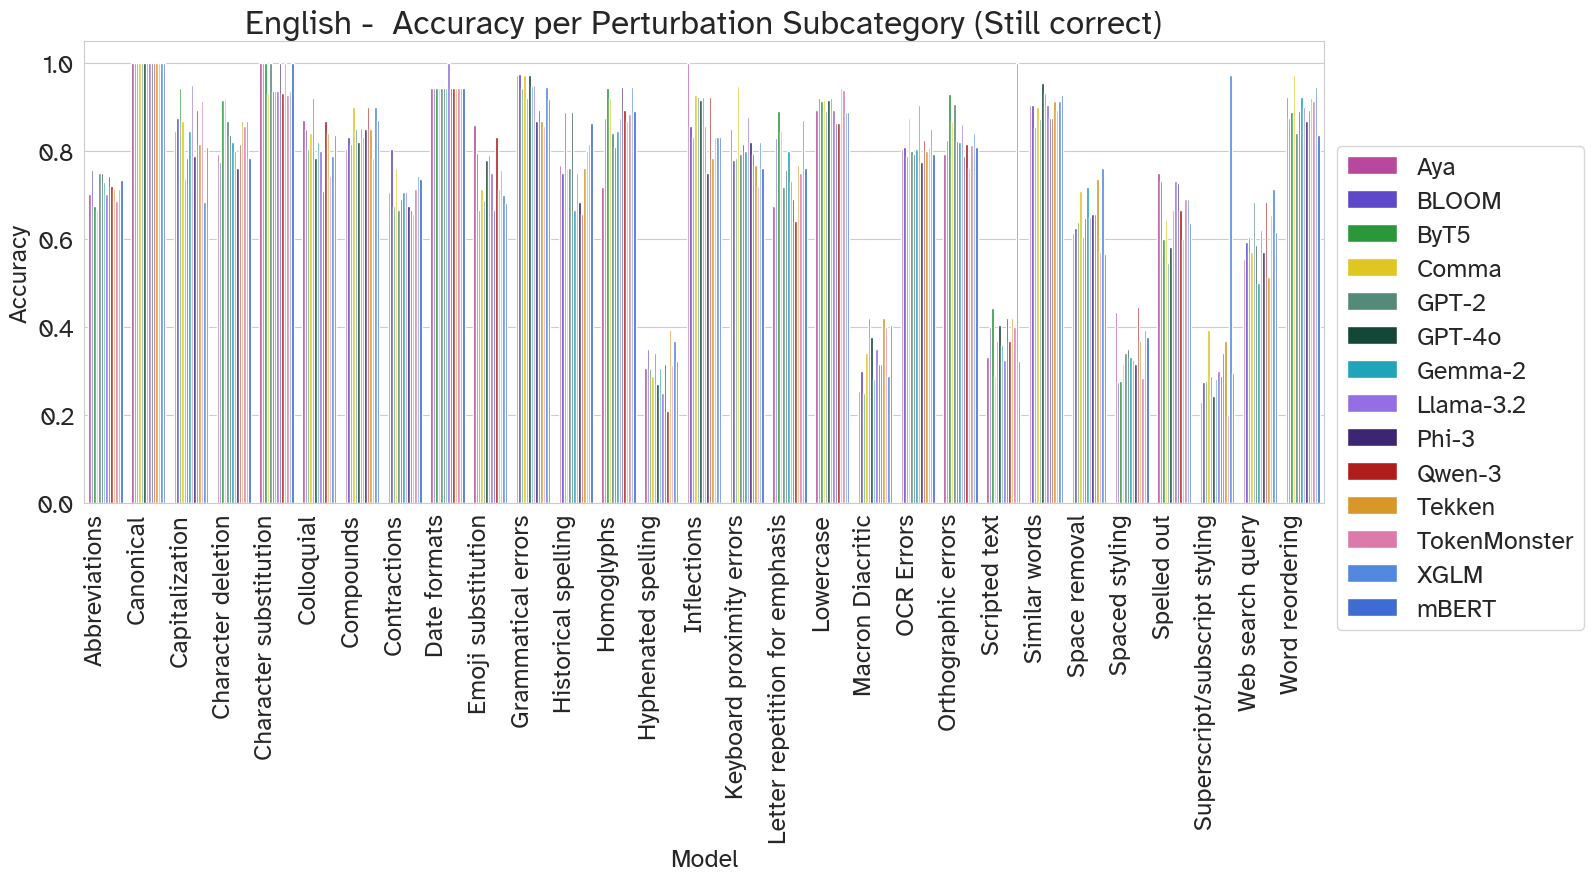

In [210]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = samples.pivot_table(
    index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="mean"
)
fig, axs = plt.subplots(1, 1, figsize=(16, 6))
sns.barplot(
    accuracies_by_model,
    x="task_pretty_name",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy")
plt.title(f"{title_pattern} Accuracy per Perturbation Subcategory {suffix}")
plt.legend(bbox_to_anchor=(1, 0.8))
plt.savefig(OUTPUT_DIR/f"combined_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [211]:
samples.sort_values(["category"])["category"].unique()

array(['', 'Grammatical errors', 'Mathematical & Scientific Notation',
       'Mathematical & Scientific Notation, Context-Dependent Ambiguities',
       'Morphological Challenges',
       'Morphological Challenges, Mathematical & Scientific Notation',
       'Morphological Challenges, Script / Orthography, Context-Dependent Ambiguities',
       'Noise', 'Script / Orthography',
       'Script / Orthography, Context-Dependent Ambiguities',
       'Script / Orthography, Language Contact',
       'Script / Orthography, Language Contact, Script / Orthography',
       'Script / Orthography, Mathematical & Scientific Notation',
       'Script / Orthography, Morphological Challenges',
       'Social Media & Informal Text', 'Structural Text Elements',
       'Temporal Expressions'], dtype=object)

Plotting Canonical into position 1
1 False False
Plotting Grammatical errors into position 2
2 False False
Plotting Spelled out into position 3
3 False False
Plotting Compounds into position 4
4 False False
Plotting Inflections into position 5
5 False False
Plotting Contractions into position 6
6 False False
Plotting Keyboard proximity errors into position 7
7 False False
Plotting OCR Errors into position 8
8 False True


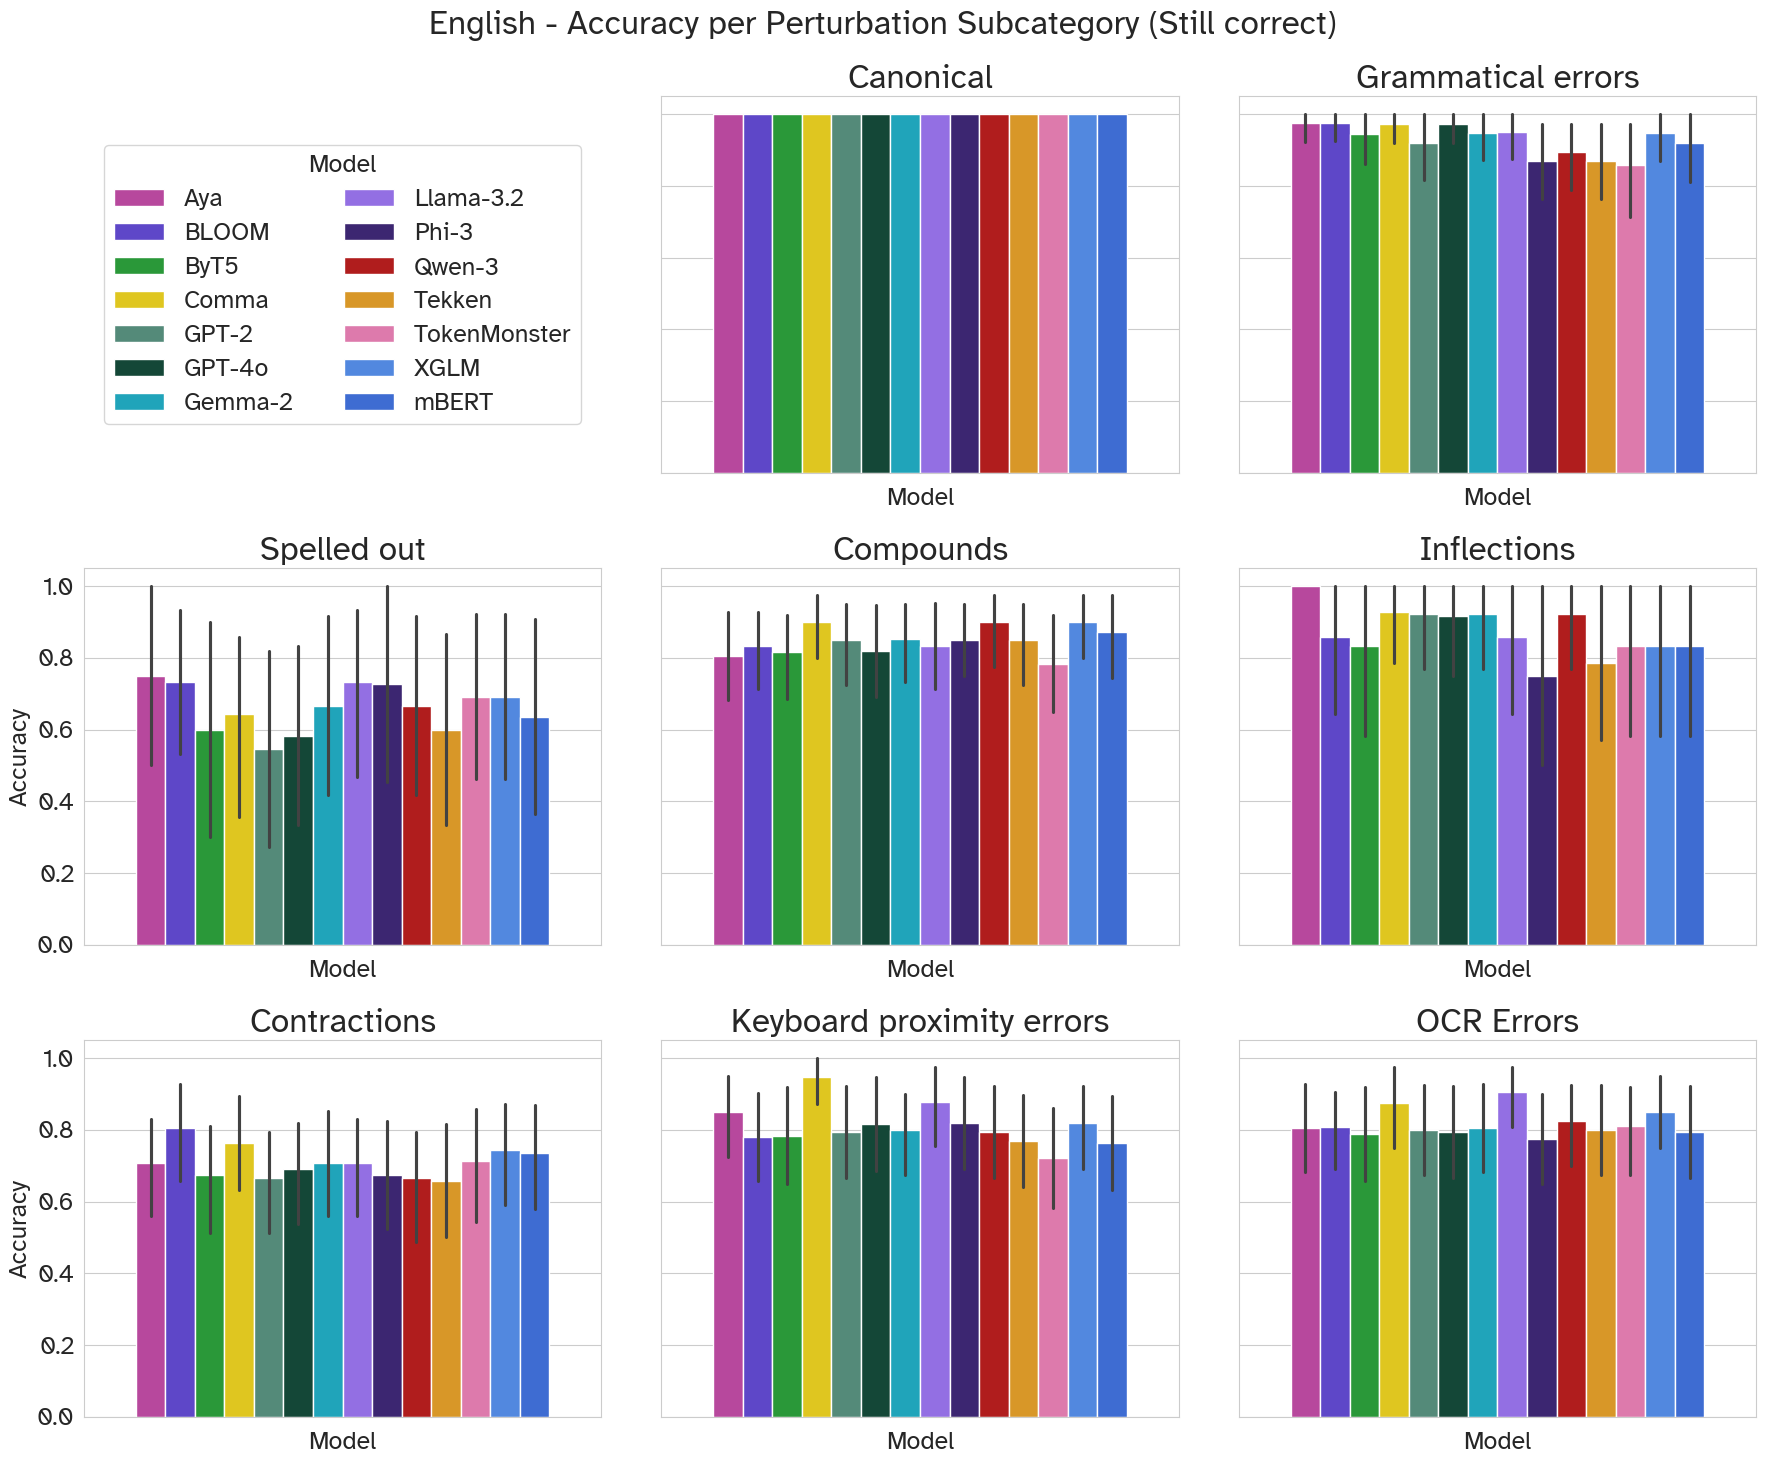

Plotting Space removal into position 0
9 False False
Plotting Character deletion into position 1
10 False False
Plotting Historical spelling into position 2
11 False False
Plotting Homoglyphs into position 3
12 False False
Plotting Abbreviations into position 4
13 False False
Plotting Orthographic errors into position 5
14 False False
Plotting Similar words into position 6
15 False False
Plotting Web search query into position 7
16 False False
Plotting Emoji substitution into position 8
17 False True


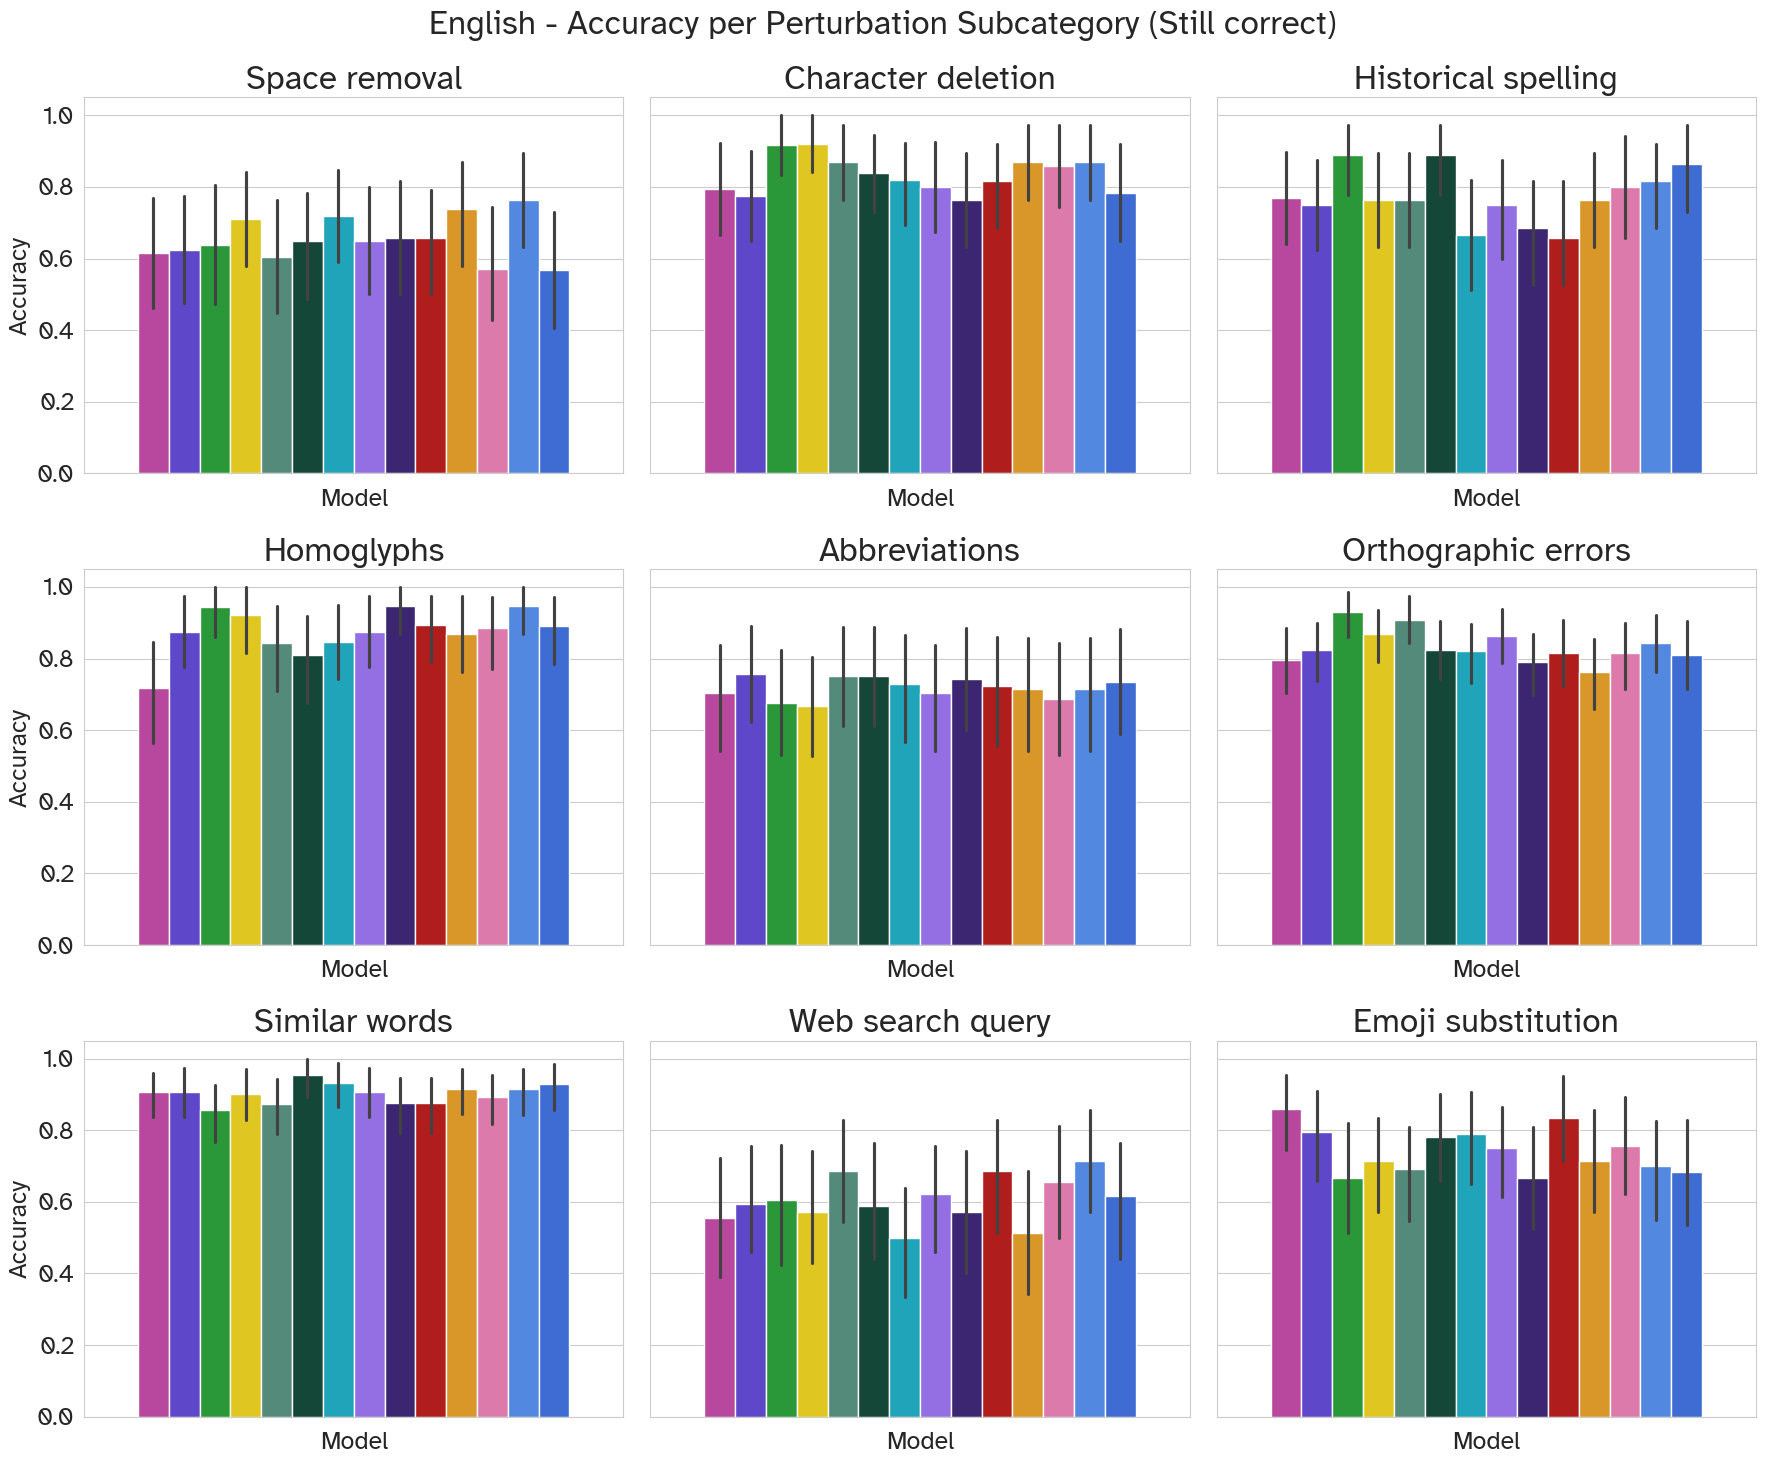

Plotting Letter repetition for emphasis into position 0
18 False False
Plotting Word reordering into position 1
19 False False
Plotting Colloquial into position 2
20 False False
Plotting Character substitution into position 3
21 False False
Plotting Hyphenated spelling into position 4
22 False False
Plotting Lowercase into position 5
23 False False
Plotting Macron Diacritic into position 6
24 False False
Plotting Scripted text into position 7
25 False False
Plotting Spaced styling into position 8
26 False True


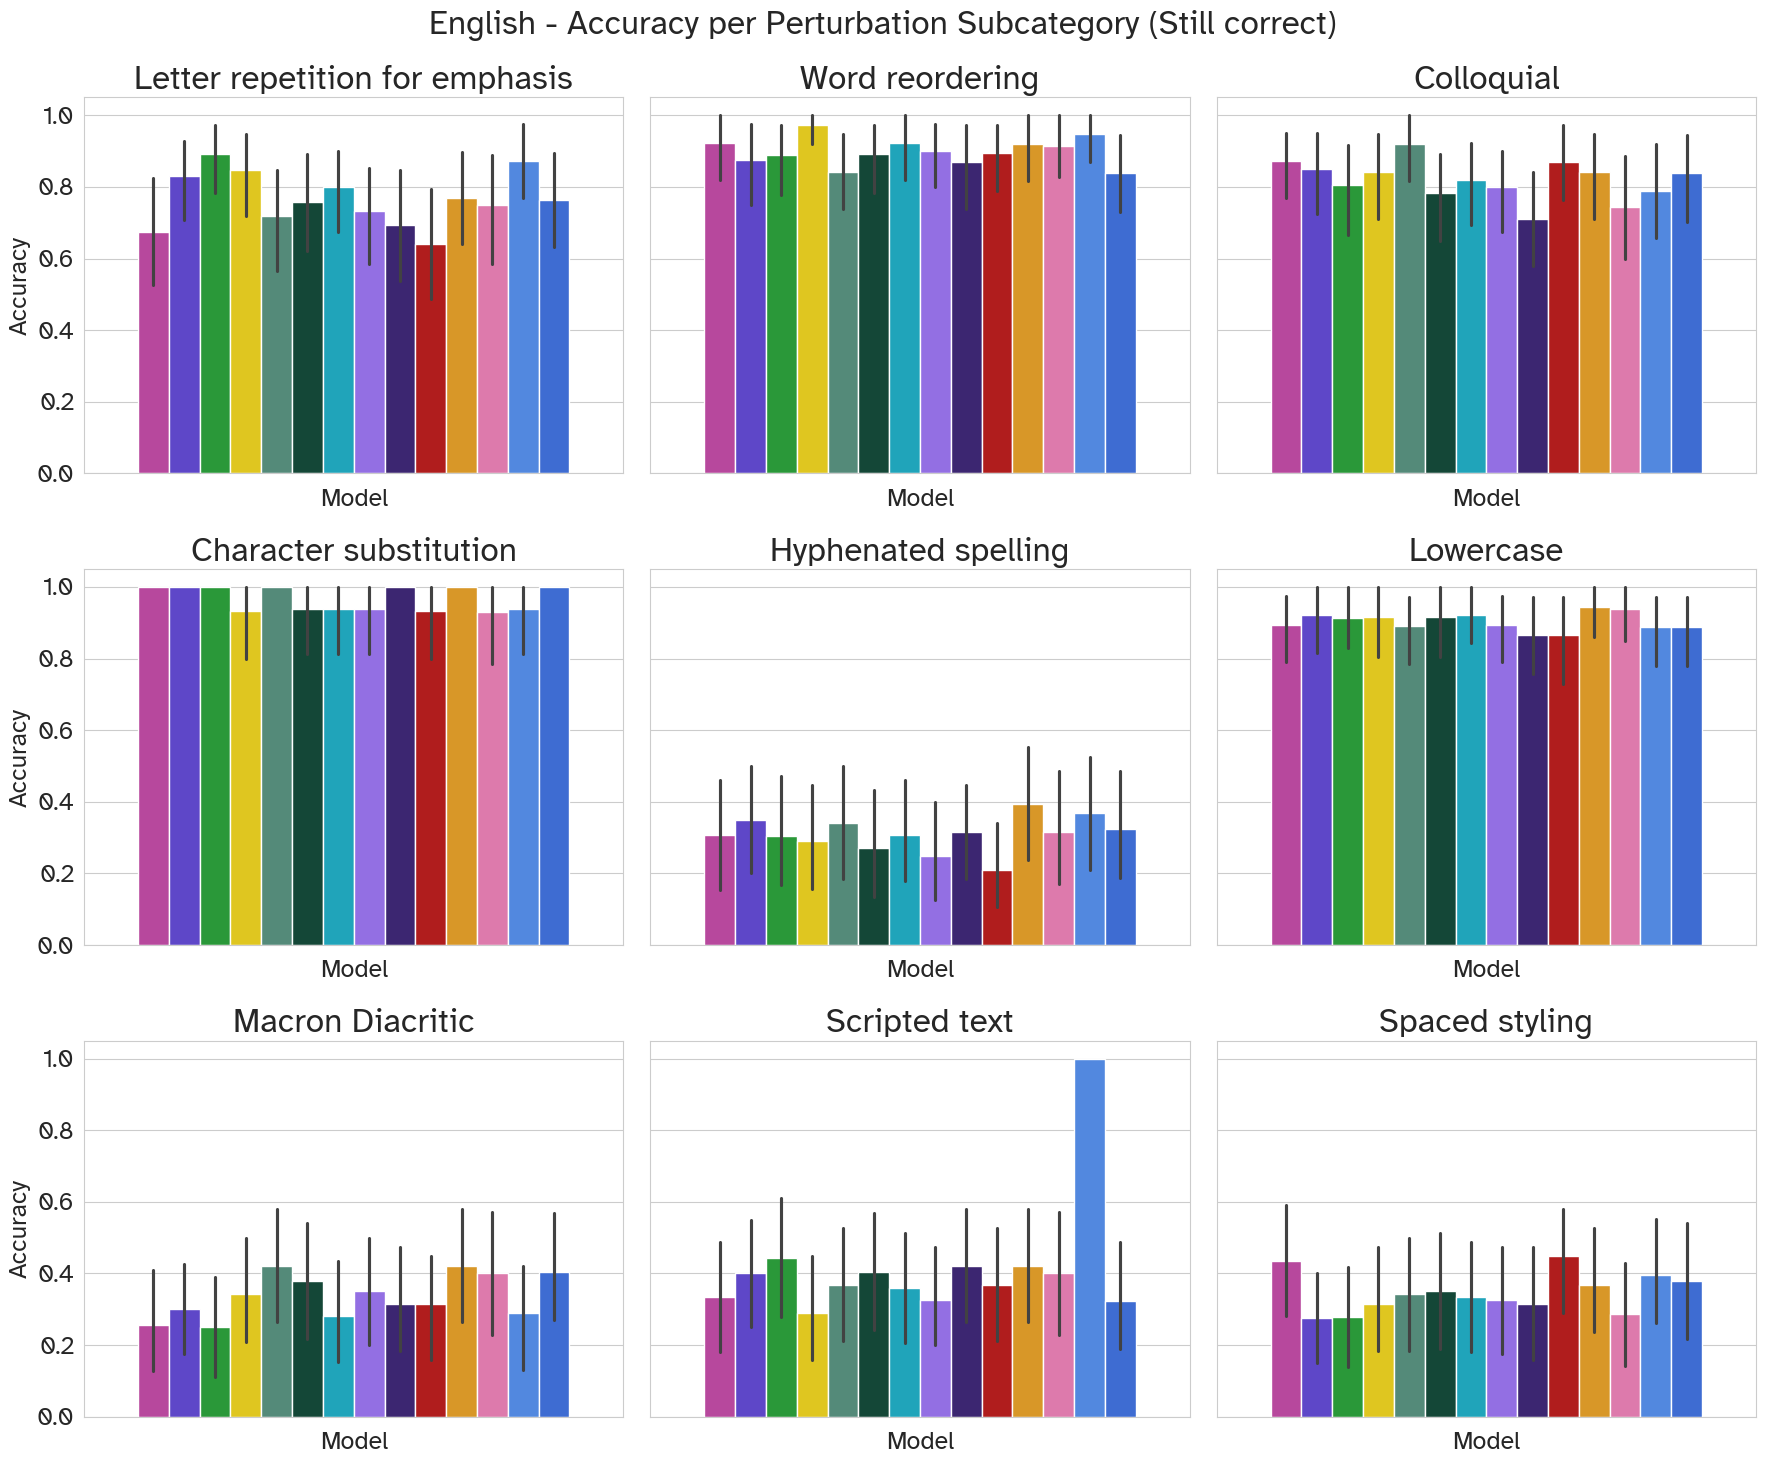

Plotting Superscript/subscript styling into position 0
27 False False
Plotting Capitalization into position 1
28 False False
Plotting Date formats into position 2
29 False False


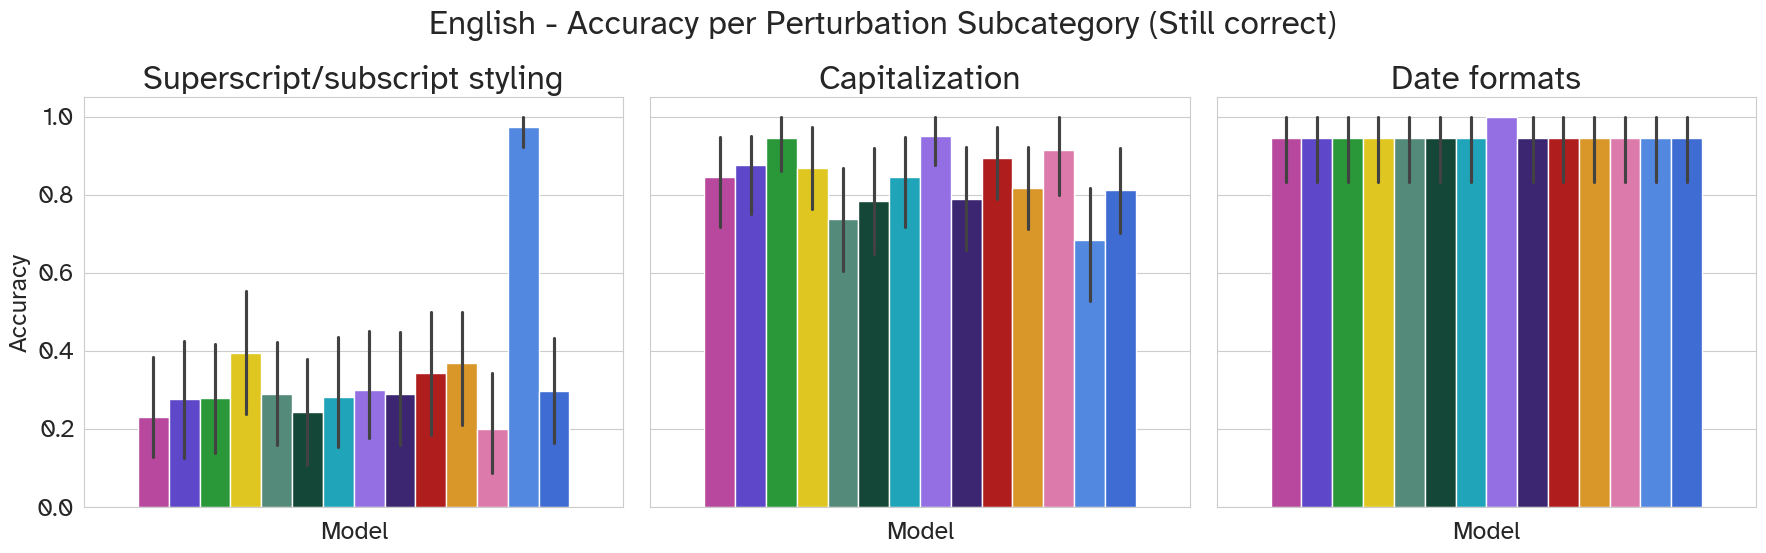

                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      1.000000
           Capitalization                 0.846154
           Character deletion             0.794872
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.378378
           Spelled out                    0.636364
           Superscript/subscript styling  0.297297
           Web search query               0.617647
           Word reordering                0.837838

[406 rows x 1 columns]


In [212]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Accuracy per Perturbation Subcategory {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
# PLOT_AXIS = "vocab_bucket"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None

samples = samples.sort_values(["model_name", "category", "set_id", "variation_id"])
samples = samples.sort_values(["model_name", "category"])
tasks = samples["task_pretty_name"].unique()
# tasks = tasks[1:]

for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples["task_pretty_name"] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC,ax=ax, legend=i == 1, palette=palette
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy")
    title = task
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=f"{title_pattern}Accuracy per Perturbation Subcategory {suffix}")
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_by_{PLOT_AXIS.lower()}_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

In [213]:
samples[samples["task_pretty_name"] == "Contractions"]["question"]

542         Dr Smith's a doctor. Occupation of Dr Smith is
564                                     The color of sky's
596           This house's 1,028,415 dollars. This house's
624                    Today's date is 29/08/2025. Today's
673                    The number of continents on Earth's
                               ...                        
15016                          "Romeo and Juliet" author's
15068         What plants need from the air to make food's
15070                                  What bees produce's
15117    In "Can you please book a flight to Paris?", t...
15119    In "Can you please book a flight to Paris?", t...
Name: question, Length: 546, dtype: object

In [214]:
# print(samples.pivot_table(index=["category", "task_pretty_name", "model_name"], values=METRIC, aggfunc="count")["Qwen"].to_markdown())
pv = samples.pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
# ["mBERT"]
pv = pv.loc["Aya"]
pv

print(pv.to_markdown())


| task_pretty_name               |   acc_norm |
|:-------------------------------|-----------:|
| Abbreviations                  |         37 |
| Canonical                      |         39 |
| Capitalization                 |         39 |
| Character deletion             |         39 |
| Character substitution         |         16 |
| Colloquial                     |         39 |
| Compounds                      |         41 |
| Contractions                   |         41 |
| Date formats                   |         18 |
| Emoji substitution             |         43 |
| Grammatical errors             |         39 |
| Historical spelling            |         39 |
| Homoglyphs                     |         39 |
| Hyphenated spelling            |         39 |
| Inflections                    |         13 |
| Keyboard proximity errors      |         40 |
| Letter repetition for emphasis |         40 |
| Lowercase                      |         38 |
| Macron Diacritic               |      

## By Category

Plotting  into position 1
1 False False
Plotting Morphological Challenges into position 2
2 False False
Plotting Social Media & Informal Text into position 3
3 False False
Plotting Grammatical errors into position 4
4 False False
Plotting Script / Orthography into position 5
5 False False
Plotting Structural Text Elements into position 6
6 False False
Plotting Noise into position 7
7 False False
Plotting Script / Orthography, Context-Dependent Ambiguities into position 8
8 False True


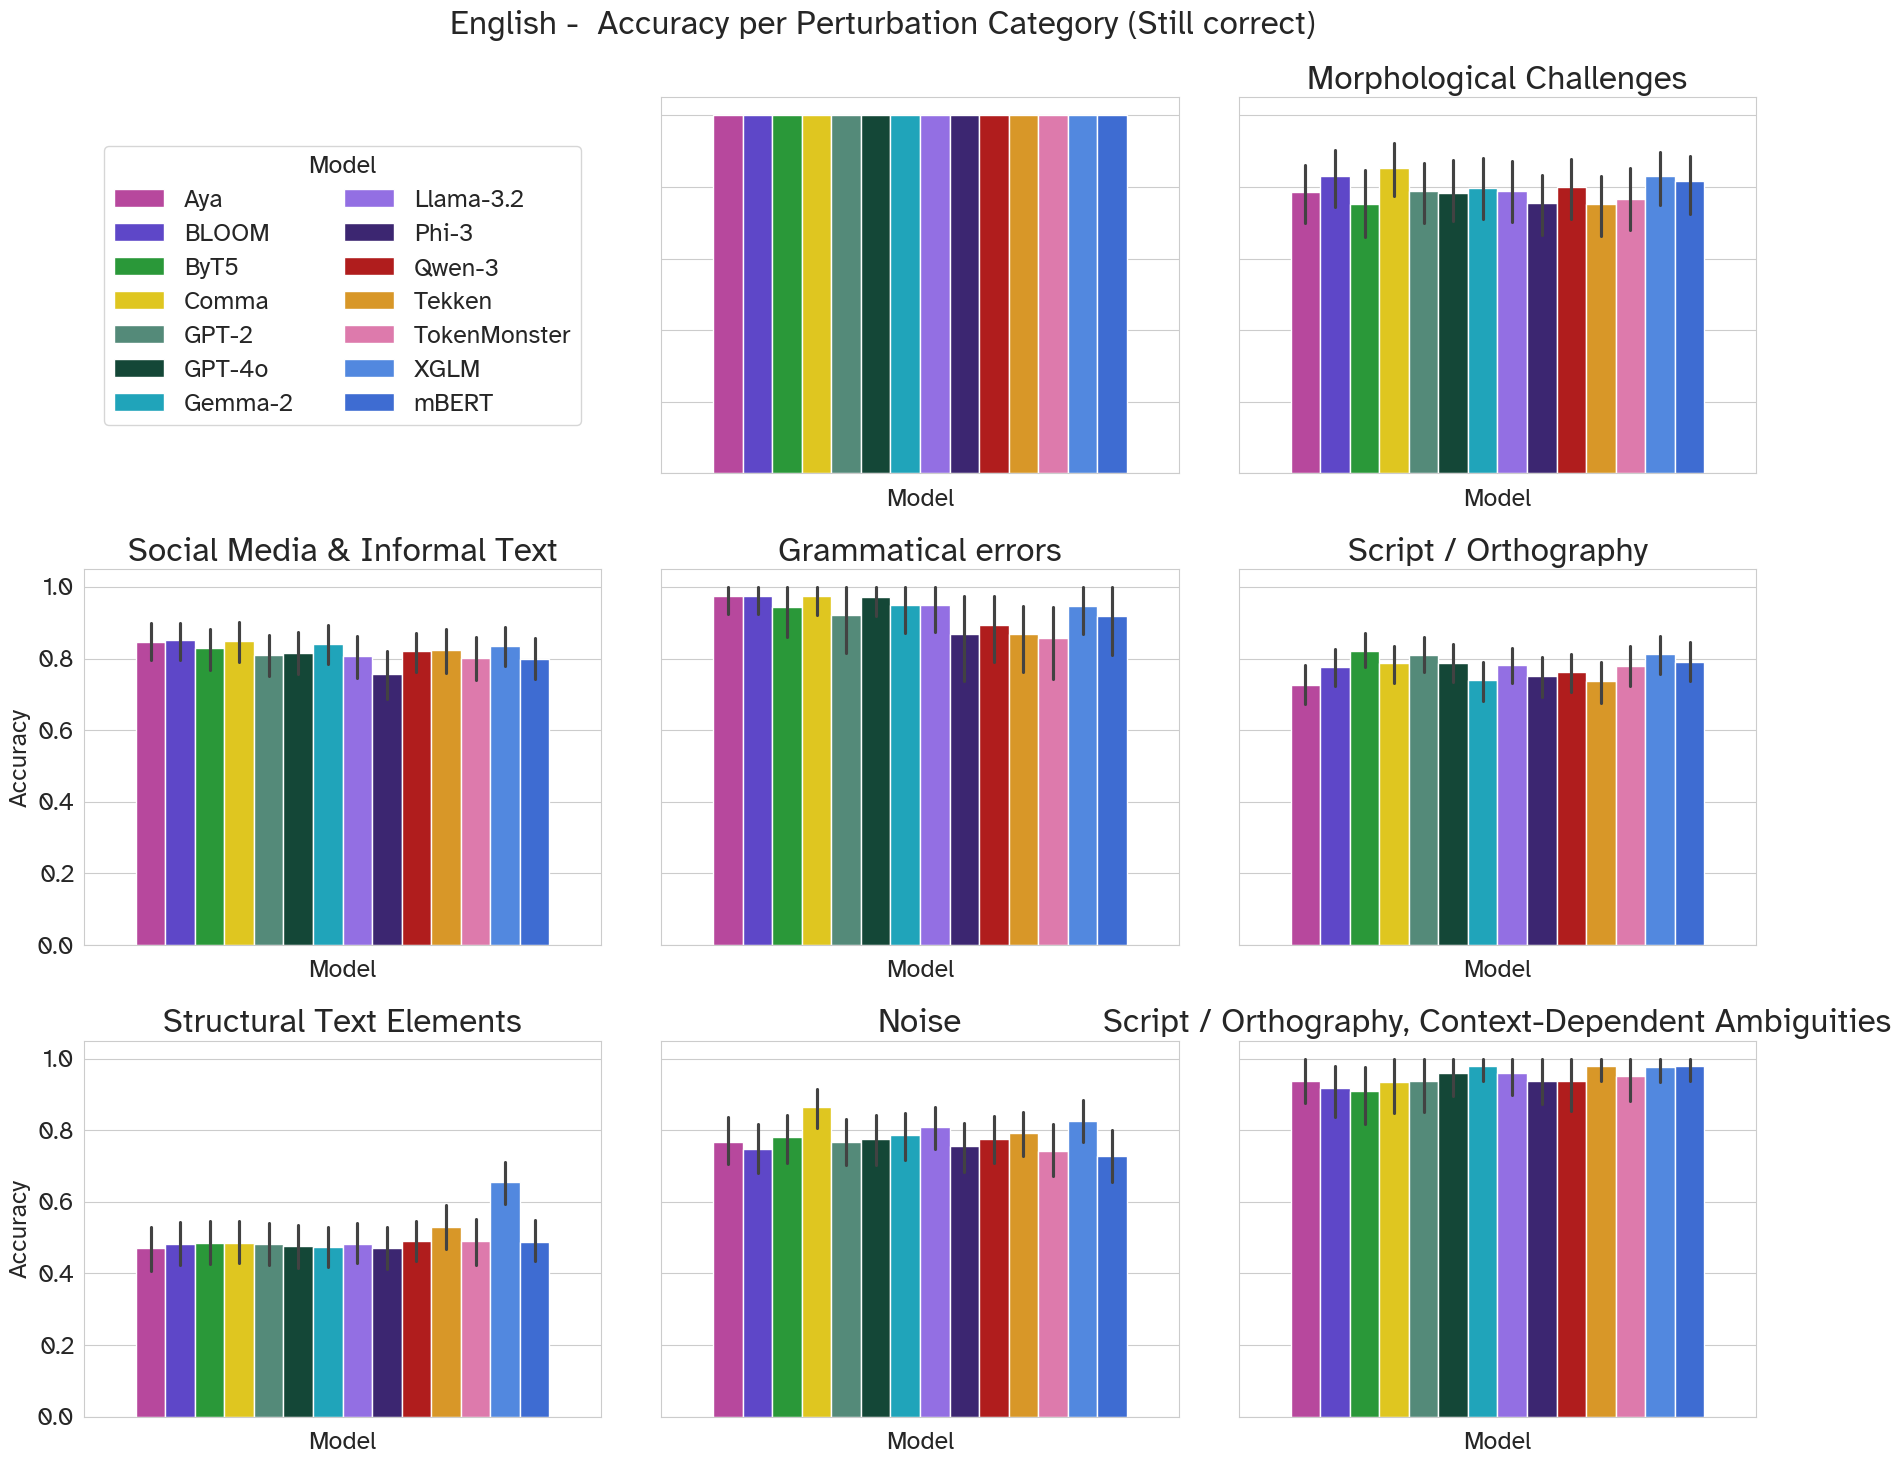

Plotting Script / Orthography, Language Contact into position 0
9 False False
Plotting Script / Orthography, Mathematical & Scientific Notation into position 1
10 False False
Plotting Temporal Expressions into position 2
11 False False
Plotting Mathematical & Scientific Notation into position 3
12 False False
Plotting Morphological Challenges, Mathematical & Scientific Notation into position 4
13 False False
Plotting Script / Orthography, Language Contact, Script / Orthography into position 5
14 False False
Plotting Mathematical & Scientific Notation, Context-Dependent Ambiguities into position 6
15 False False
Plotting Morphological Challenges, Script / Orthography, Context-Dependent Ambiguities into position 7
16 False False
Plotting Script / Orthography, Morphological Challenges into position 8
17 False True


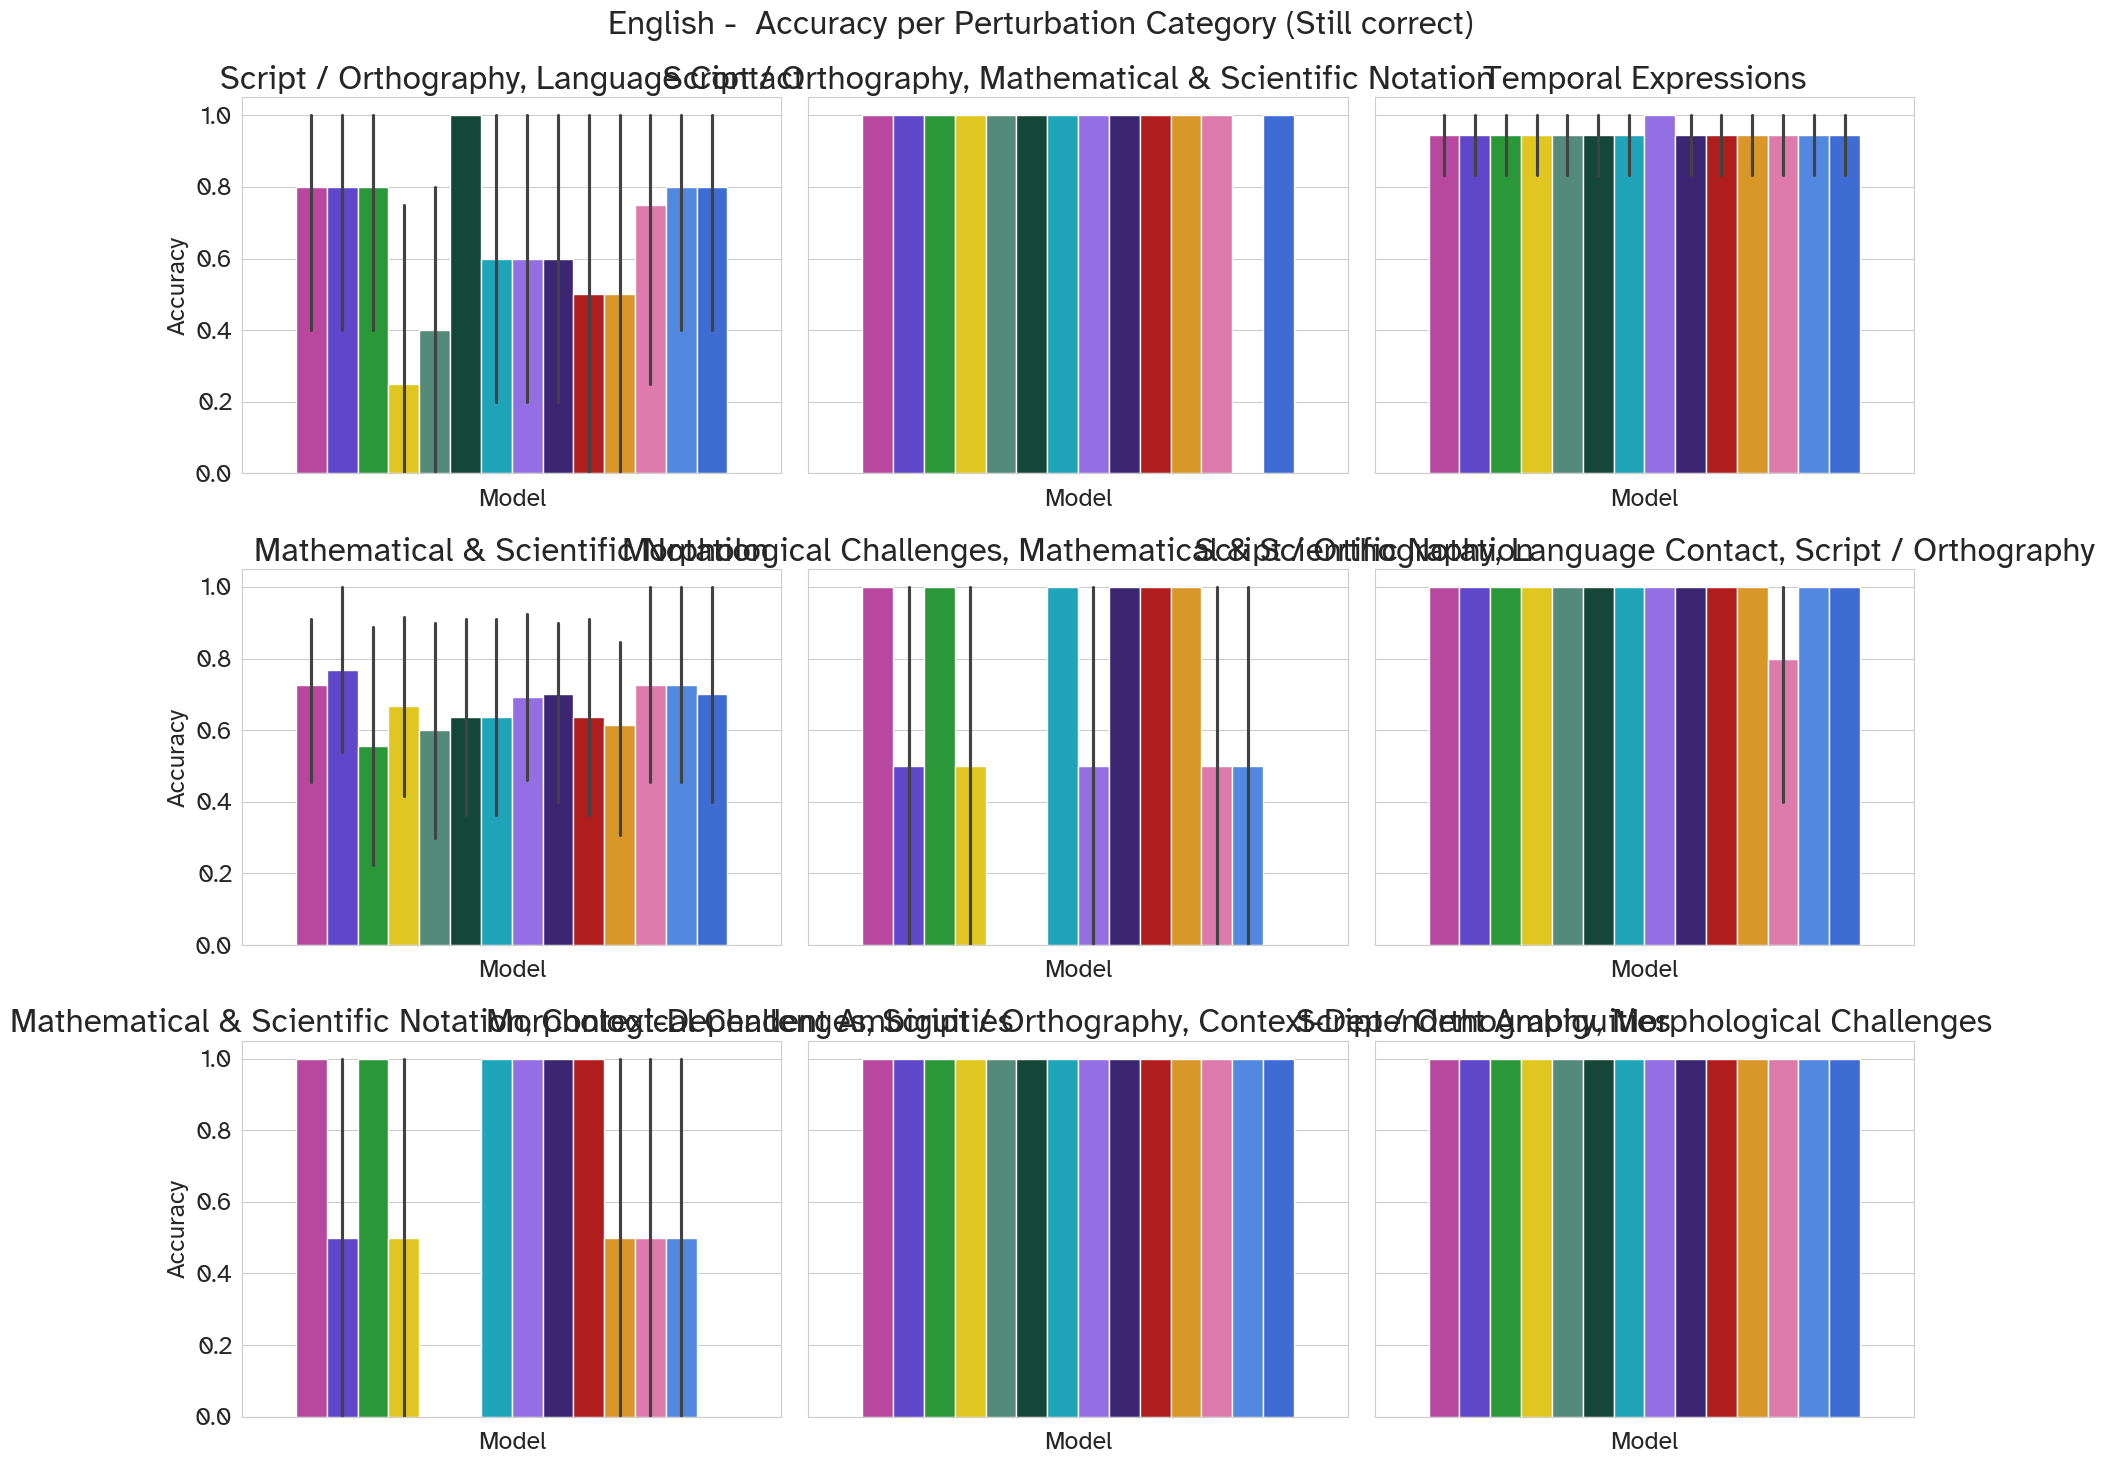

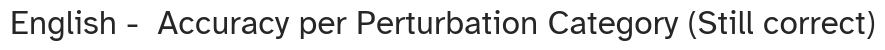

                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      1.000000
           Capitalization                 0.846154
           Character deletion             0.794872
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.378378
           Spelled out                    0.636364
           Superscript/subscript styling  0.297297
           Web search query               0.617647
           Word reordering                0.837838

[406 rows x 1 columns]


In [215]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy per Perturbation Category {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
# PLOT_AXIS = "vocab_bucket"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None
## category might have multiple entries
FILTER_AXIS = "category"

samples = samples.sort_values(["model_name", "set_id", "variation_id"])
tasks = samples[FILTER_AXIS].unique()
for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples[FILTER_AXIS] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC,ax=ax, legend=i == 1, palette=palette
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy")
    title = task
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy per Perturbation Category {suffix}")
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_by_{PLOT_AXIS.lower()}_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

## Canonical Eng vs Other Langs

In [216]:
samples['acc_norm']

0        1
531      1
532      1
543      1
544      1
        ..
15122    1
15123    1
15124    1
15125    1
15126    1
Name: acc_norm, Length: 15144, dtype: int64

In [217]:
samples["is_canonical"] & (samples["set_id"].isin(list(range(300,345)) + [str(i) for i in range(300, 345)]))

0        False
531      False
532      False
543      False
544      False
         ...  
15122    False
15123    False
15124    False
15125    False
15126    False
Length: 15144, dtype: bool

In [218]:
samples["set_id"].isin(list(range(300,345)))

0        False
531      False
532      False
543      False
544      False
         ...  
15122    False
15123    False
15124    False
15125    False
15126    False
Name: set_id, Length: 15144, dtype: bool

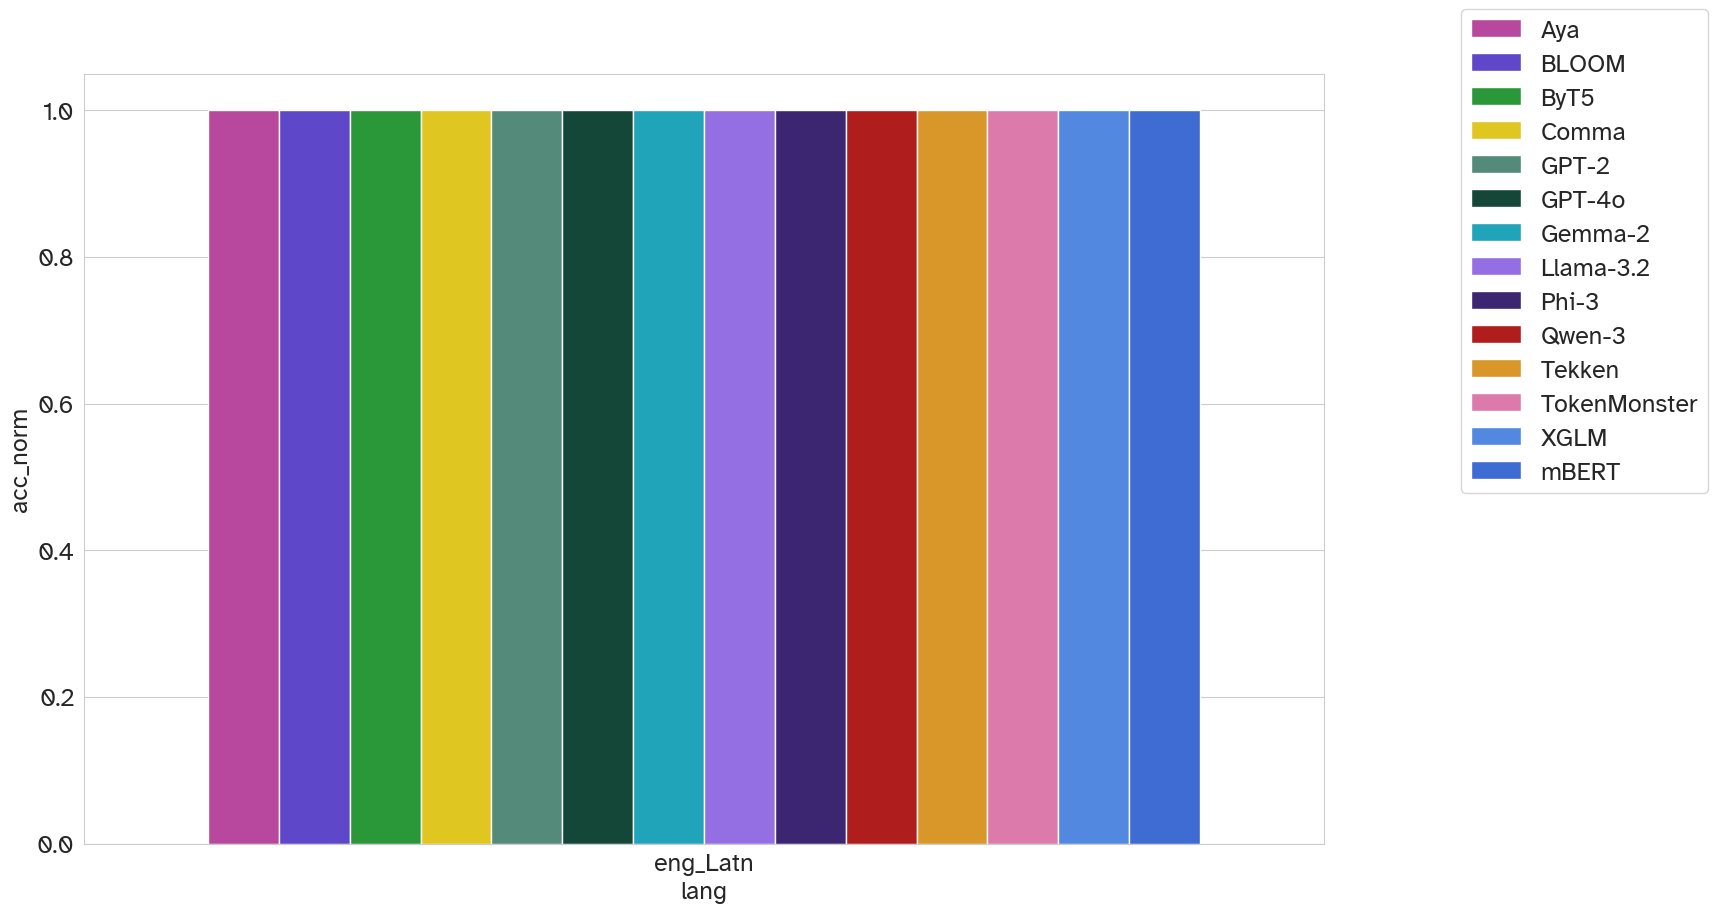

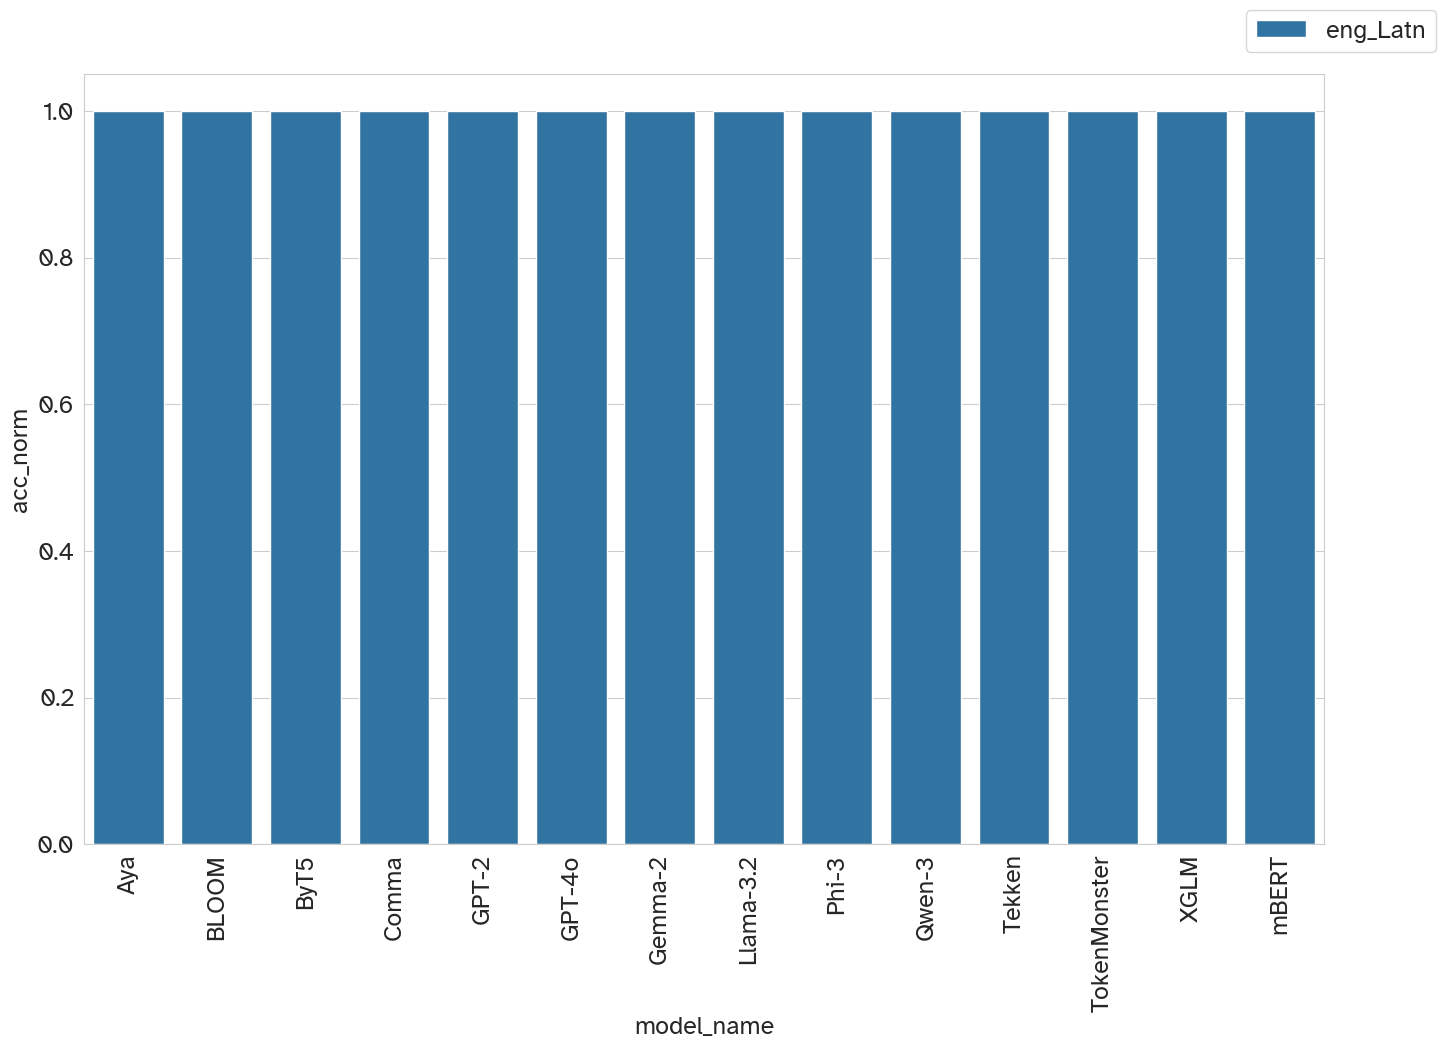

| lang     |   acc_norm |
|:---------|-----------:|
| eng_Latn |          1 |


In [225]:
filter_ = samples["is_canonical"] & (samples["set_id"].isin(list(range(300,345)) + [str(i) for i in range(300, 345)] + [str(float(i)) for i in range(300, 345)]))

fig = plt.figure(figsize=(16, 10))
sns.barplot(samples[filter_], x="lang", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
plt.legend(bbox_to_anchor=(1.1,1.1))
plt.show()

fig = plt.figure(figsize=(16, 10))
sns.barplot(samples[filter_], x="model_name", y=METRIC, hue="lang")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.1,1.1))
plt.show()

print(samples[filter_].pivot_table(index=["lang"], values=METRIC, aggfunc="mean").sort_values(METRIC, ascending=False).to_markdown())

In [220]:
# samples["Lang"].unique()
samples[filter_ & (samples["model_name"] == "mBERT")]

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id,canonical_acc_norm,canonical-perturbed_acc_norm
494,0,3,"[[[-6.46875, False]], [[-8.875, False]], [[-7....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,Dr Smith is a doctor. Occupation of Dr Smith is,...,13,11,12,11,Canonical,Medium,True,0.0,NaN,NaN
495,1,1,"[[[-4.6875, False]], [[-2.4375, True]], [[-4.8...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The color of the sky is,...,6,6,6,5,Canonical,Medium,True,0.0,NaN,NaN
496,2,0,"[[[-3.71875, True]], [[-12.875, False]], [[-11...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,"The price of this house is 1,028,415 dollars. ...",...,24,24,20,16,Canonical,Medium,True,0.0,NaN,NaN
497,3,1,"[[[-11.9375, False]], [[-7.875, False]], [[-10...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,Today's date is 29/08/2025. Today is,...,19,18,13,14,Canonical,Medium,True,0.0,NaN,NaN
498,5,3,"[[[-6.03125, False]], [[-7.28125, False]], [[-...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The capital city of Iran is,...,6,6,6,5,Canonical,Medium,True,0.0,NaN,NaN
499,6,3,"[[[-6.09375, False]], [[-6.40625, False]], [[-...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The number of days in a week is,...,8,8,8,6,Canonical,Medium,True,0.0,NaN,NaN
500,7,0,"[[[-4.84375, False]], [[-8.0625, False]], [[-7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The number of hours in a day is,...,8,8,8,6,Canonical,Medium,True,0.0,NaN,NaN
501,8,0,"[[[-8.125, False]], [[-8.8125, False]], [[-8.7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The number of legs a cow has is,...,8,8,8,7,Canonical,Medium,True,0.0,NaN,NaN
502,9,3,"[[[-6.15625, False]], [[-7.875, False]], [[-5....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The number of minutes in 2 hours is,...,9,9,9,7,Canonical,Medium,True,0.0,NaN,NaN
503,10,0,"[[[-4.53125, False]], [[-8.0625, False]], [[-7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_english_canonical,The number of months in a year is,...,8,8,8,6,Canonical,Medium,True,0.0,NaN,NaN


### By Model

In [221]:
OUTPUT_DIR.absolute()

PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/notebooks/output/paper-results-v5/english/still correct')

Plotting Aya into position 1
Plotting BLOOM into position 2
Plotting ByT5 into position 3
Plotting Comma into position 4


/var/folders/d7/6swf_cn561v8n6hw_bgg04lh0000gn/T/ipykernel_30275/4018058729.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


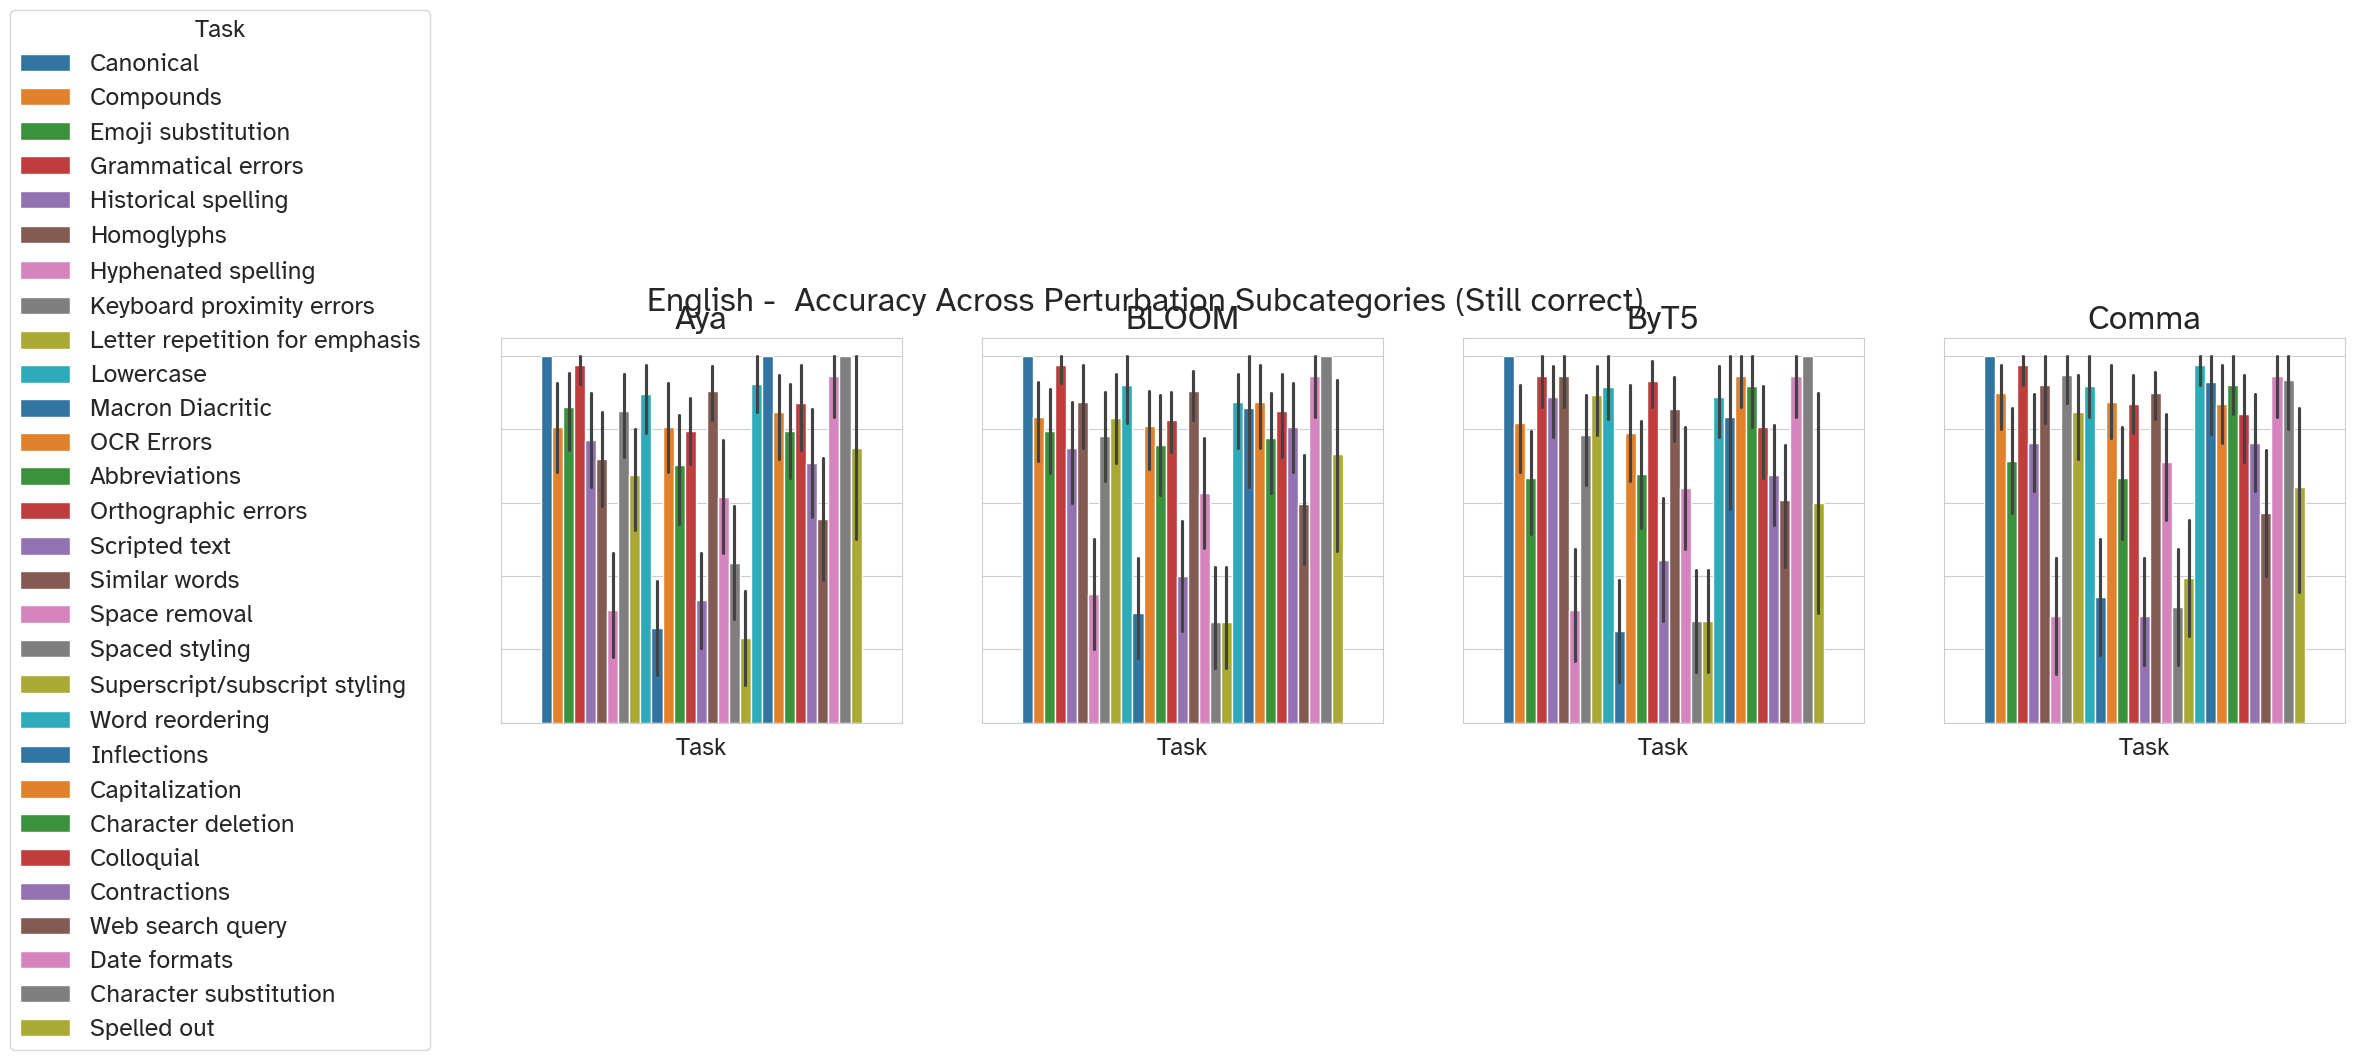

Plotting GPT-2 into position 0
Plotting GPT-4o into position 1
Plotting Gemma-2 into position 2
Plotting Llama-3.2 into position 3
Plotting Phi-3 into position 4


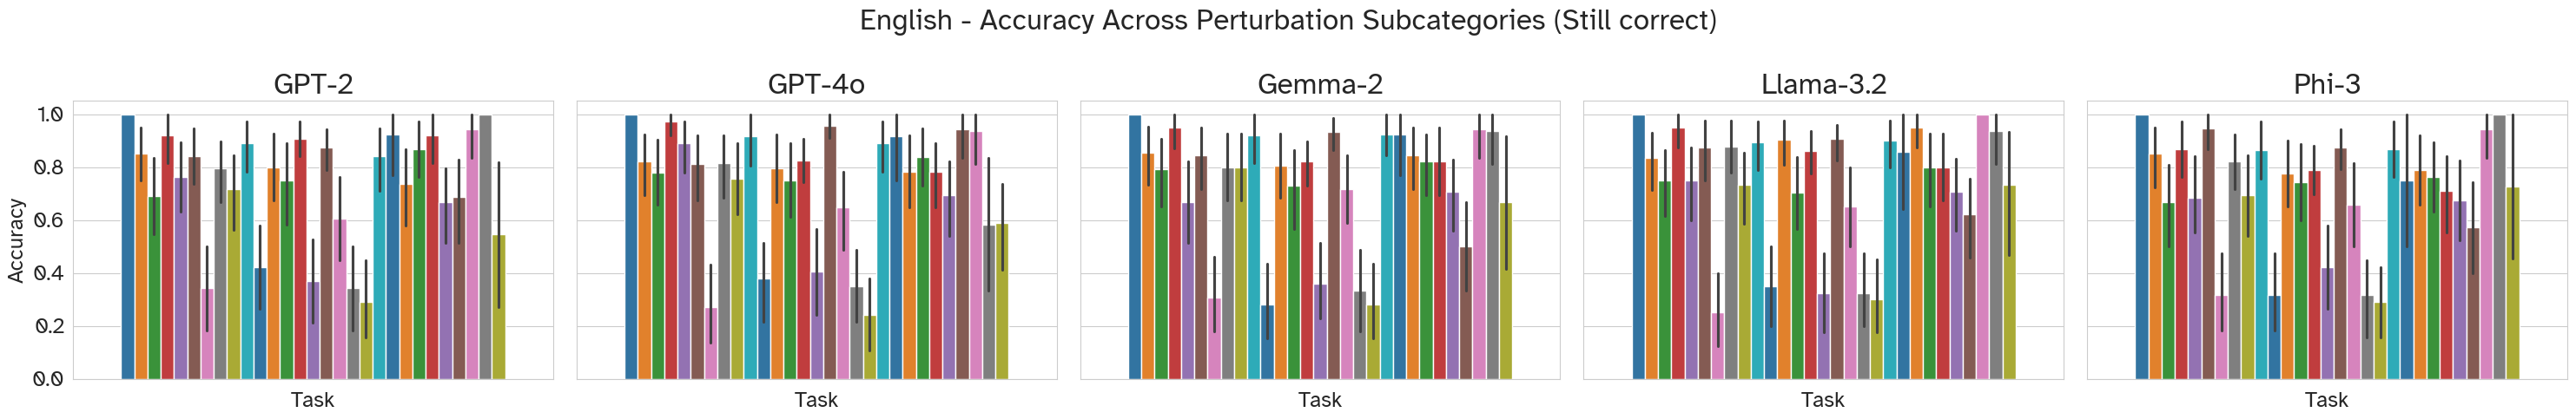

Plotting Qwen-3 into position 0
Plotting Tekken into position 1
Plotting TokenMonster into position 2
Plotting XGLM into position 3
Plotting mBERT into position 4


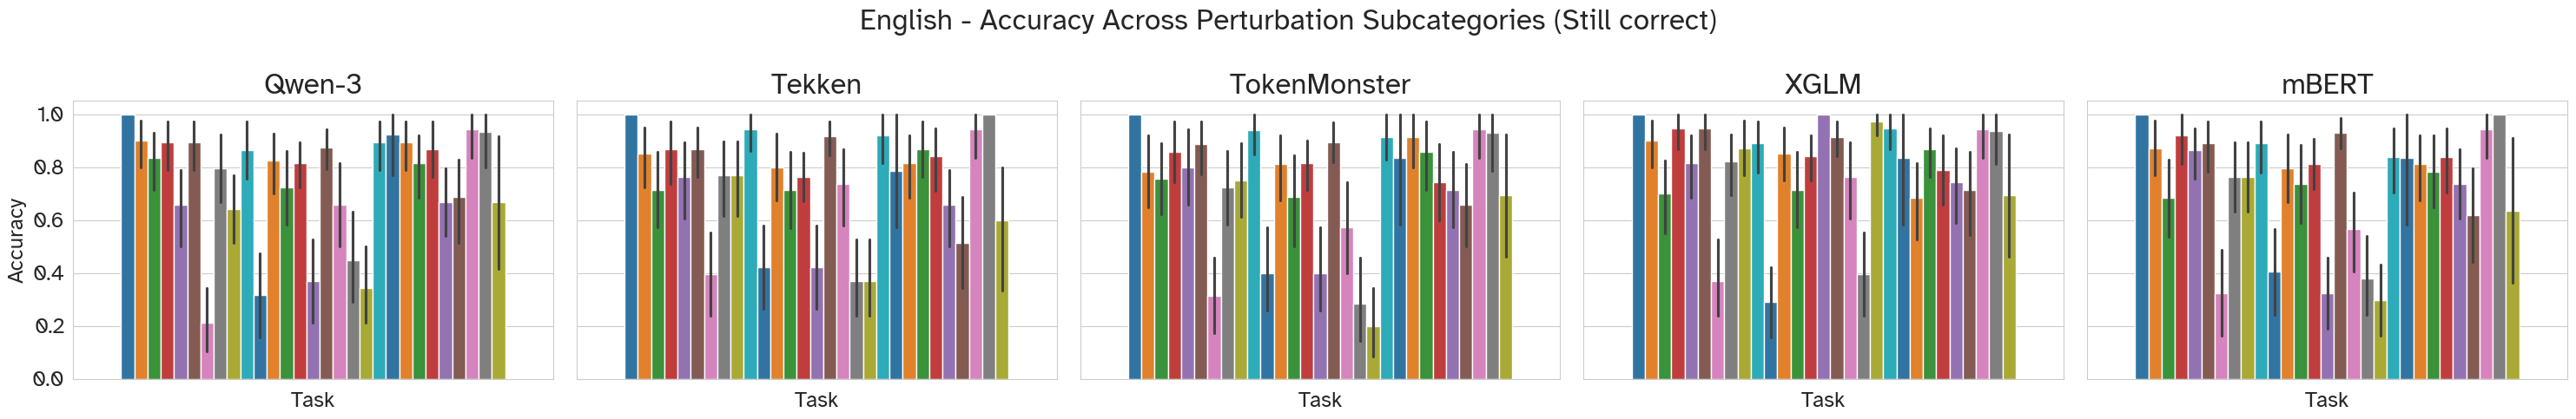

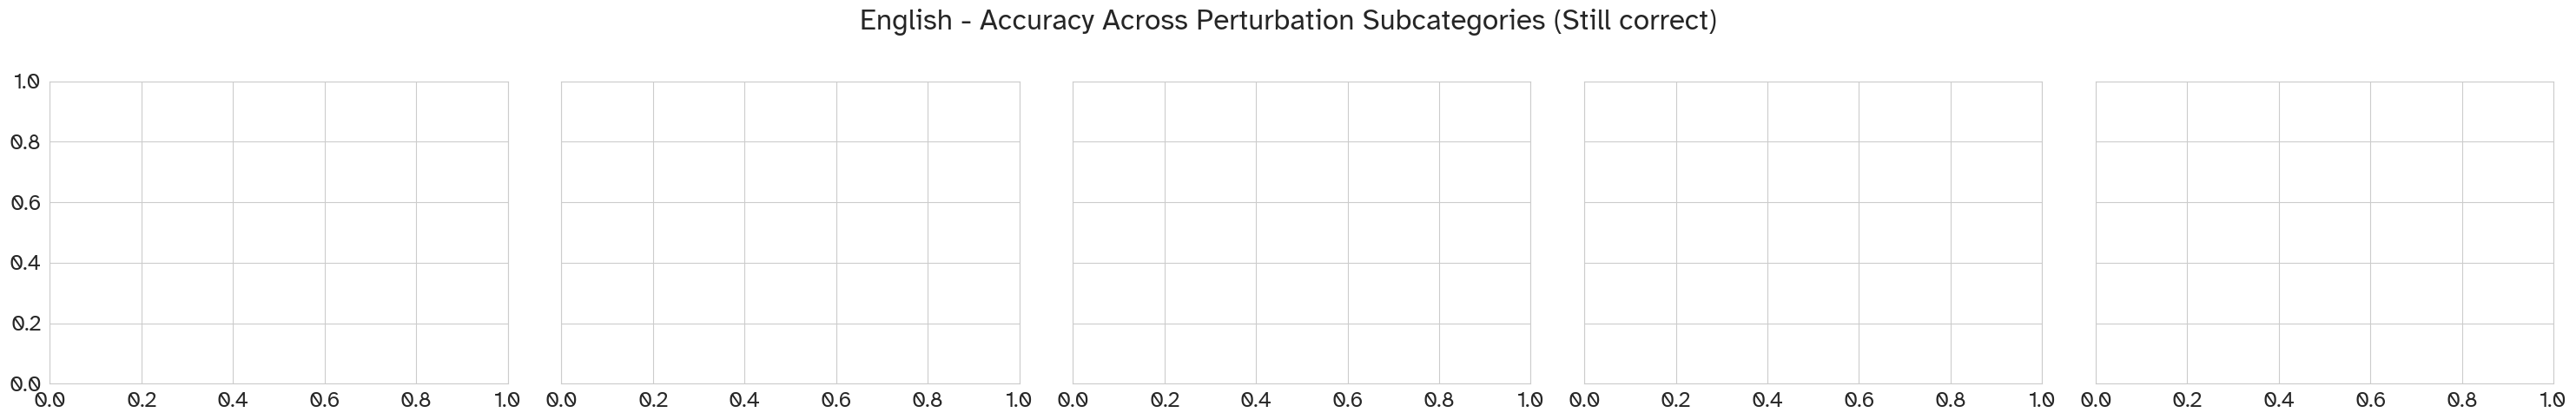

                                          acc_norm
model_name task_pretty_name                       
Aya        Abbreviations                  0.702703
           Canonical                      1.000000
           Capitalization                 0.846154
           Character deletion             0.794872
           Character substitution         1.000000
...                                            ...
mBERT      Spaced styling                 0.378378
           Spelled out                    0.636364
           Superscript/subscript styling  0.297297
           Web search query               0.617647
           Word reordering                0.837838

[406 rows x 1 columns]


In [222]:
nrows, ncols = 1, 5
PLOT_AXIS="model_name"
# PLOT_AXIS="vocab_bucket"
HUE="task_pretty_name"
# HUE="task"
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy Across Perturbation Subcategories {suffix}"
)
fig_cnt = 0
models = samples[PLOT_AXIS].unique()
sorted(models)
for i, model in enumerate(models, 1):
    print(f"Plotting {model} into position {i % len(axs)}")
    filter_ = samples[PLOT_AXIS] == model
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=HUE, y=METRIC, palette="tab10", ax=ax, legend=i == 1
    )
    ax.set_xlabel("Task")
    ax.set_ylabel(f"Accuracy")
    title=model
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(models) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Task", loc="center", ncol=1)
        axs[1].legend().set_visible(False)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig_cnt += 1
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=f"{title_pattern}Accuracy Across Perturbation Subcategories {suffix}")
# Hide any unused subplots if there are fewer than 6 tasks
# for j in range((len(models)+1) % (ncols * nrows), ncols * nrows):
#     axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

print(accuracies_by_model)

### Examples per perturbation

In [223]:
pv = all_samples[all_samples["model_name"] == "Aya"].pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
pv.to_csv(OUTPUT_DIR/"sample_counts.csv")
pv


acc_norm
model_name task_pretty_name                        
Aya        Abbreviations                         37
           Canonical                             40
           Capitalization                        40
           Character deletion                    40
           Character substitution                16
           Colloquial                            40
           Compounds                             42
           Contractions                          41
           Date formats                          18
           Emoji substitution                    44
           Grammatical errors                    40
           Historical spelling                   40
           Homoglyphs                            40
           Hyphenated spelling                   40
           Inflections                           14
           Keyboard proximity errors             41
           Letter repetition for emphasis        41
           Lowercase                             38
           Macron Diacritic                      40
           OCR Errors                            42
           Orthographic errors                   80
           Scripted text                         40
           Similar words                         74
           Space removal                         40
           Spaced styling                        40
           Spelled out                           15
           Superscript/subscript styling         40
           Web search query                      37
           Word reordering                       40

### Against tokenizer props

#### Token count

In [187]:
samples["token_counts"]

KeyError: 'token_counts'

In [88]:
models = samples["model_name"].unique()

sns.histplot(samples, x="model_name", y="token_counts")

ValueError: Could not interpret value `token_counts` for `y`. An entry with this name does not appear in `data`.

In [ ]:
samples.columns

Index(['doc_id', 'target', 'resps', 'metrics', 'acc', 'acc_norm', 'model_name',
       'task', 'question', 'choices', 'answer', 'answer_label', 'split',
       'subcategories', 'categories', 'lang', 'second_lang', 'notes', 'id',
       'set_id', 'variation_id',
       'vanilla_cos_sim_to_canonical.CohereLabs/aya-expanse-8b',
       'vanilla_cos_sim_to_canonical.Qwen/Qwen3-8B',
       'vanilla_cos_sim_to_canonical.bigscience/bloom',
       'vanilla_cos_sim_to_canonical.common-pile/comma-v0.1-1t',
       'vanilla_cos_sim_to_canonical.facebook/xglm-564M',
       'vanilla_cos_sim_to_canonical.google-bert/bert-base-multilingual-cased',
       'vanilla_cos_sim_to_canonical.google/byt5-small',
       'vanilla_cos_sim_to_canonical.google/gemma-2-2b',
       'vanilla_cos_sim_to_canonical.gpt2',
       'vanilla_cos_sim_to_canonical.meta-llama/Llama-3.2-1B',
       'vanilla_cos_sim_to_canonical.microsoft/Phi-3-mini-4k-instruct',
       'vanilla_cos_sim_to_canonical.mistralai/tekken',
       'vani

In [ ]:
toks = samples["tokenizer_name"].unique()
tok_count_cols = [f"token_counts.{tok_name}" for tok_name in toks]
tok_counts = samples[tok_count_cols]
tok_counts.columns=toks
tok_counts 


,google/byt5-small,bigscience/bloom,common-pile/comma-v0.1-1t,google-bert/bert-base-multilingual-cased,Qwen/Qwen3-8B,gpt2,CohereLabs/aya-expanse-8b
0,80,35,41,25,23,42,22
1,26,11,12,9,10,15,6
2,20,8,9,7,8,12,5
3,49,22,26,19,25,22,23
4,40,14,23,13,22,20,20
...,...,...,...,...,...,...,...
4076,30,12,13,7,10,13,6
4077,29,10,10,7,9,12,5
4078,18,8,10,6,6,11,5
4079,27,10,13,9,10,14,7


In [ ]:
samples["tokenizer_name"]

0               google/byt5-small
1               google/byt5-small
2               google/byt5-small
3               google/byt5-small
4               google/byt5-small
                  ...            
4076    CohereLabs/aya-expanse-8b
4077    CohereLabs/aya-expanse-8b
4078    CohereLabs/aya-expanse-8b
4079    CohereLabs/aya-expanse-8b
4080    CohereLabs/aya-expanse-8b
Name: tokenizer_name, Length: 4081, dtype: object

In [ ]:
for i, row in samples.iterrows():
    samples.iloc[i, "token_count"]=

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.google/gemma-2-2b,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,answer_choice,task_pretty_name,is_canonical
0,0,0,"[[[-7.9375, False]], [[-15.0625, False]], [[-1...","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Dr Gülçiçek Bölükbaşı bir doktordur. Gülçiçek ...,...,23,42,28,37,26,26,54,doktorluktur,Derivations,False
1,1,2,"[[[-11.875, False]], [[-12.1875, False]], [[-1...","[acc, acc_norm]",1,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün renklenişi,...,7,15,8,12,9,8,17,mavidir,Derivations,False
2,2,3,"[[[-7.21875, False]], [[-11.0625, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün rengi,...,5,12,8,9,8,6,14,mavimsidir,Derivations,False
3,3,0,"[[[-8.5625, False]], [[-16.25, False]], [[-18....","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,"Bu ev 5,850,000 Lira fiyatlı. Bu evin maaliyeti",...,22,22,20,28,25,20,24,"5,850,000 TL'dir",Derivations,False
4,4,3,"[[[-13.8125, False]], [[-13.9375, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Bugün 17/08/1998'dir. Bugünkü tarihi,...,20,20,16,24,21,16,25,17/8/1998'dir,Derivations,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4076,6,0,"[[[-16.75, False]], [[-12.625, False]], [[-12....","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir dakikadaki saniye sayısı,...,9,13,8,13,9,9,16,altmıştır,Spelled out,False
4077,7,2,"[[[-9.0625, False]], [[-8.125, False]], [[-8.5...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir altıgenin kenar sayısı,...,8,12,7,12,9,9,16,altıdır,Spelled out,False
4078,8,2,"[[[-11.6875, False]], [[-14.4375, False]], [[-...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Yüzün yüzde onu,...,5,11,5,10,6,5,11,ondur,Spelled out,False
4079,9,0,"[[[-11.875, False]], [[-15.375, False]], [[-16...","[acc, acc_norm]",1,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Seksenin yüzde yirmi beşi,...,9,14,10,14,11,9,16,yirmidir,Spelled out,False
